In [ ]:
import kagglehub
from pandas import read_csv, merge
import os
# this notebook will take a closer look at how the dataset has organised the genre information

In [ ]:
# Download latest version
path = kagglehub.dataset_download("hernan4444/anime-recommendation-database-2020")

print("Path to dataset files:", path)

# load anime synopsis dataset from kaggle
animelist_synoposis = read_csv(os.path.join(path, "anime_with_synopsis.csv"))

Path to dataset files: /root/.cache/kagglehub/datasets/hernan4444/anime-recommendation-database-2020/versions/7


In [ ]:
animelist_synoposis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16214 entries, 0 to 16213
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MAL_ID     16214 non-null  int64 
 1   Name       16214 non-null  object
 2   Score      16214 non-null  object
 3   Genres     16214 non-null  object
 4   sypnopsis  16206 non-null  object
dtypes: int64(1), object(4)
memory usage: 633.5+ KB


In [ ]:
animelist_synoposis.head()

,MAL_ID,Name,Score,Genres,sypnopsis
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space","In the year 2071, humanity has colonized sever..."
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space","other day, another bounty—such is the life of ..."
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen","Vash the Stampede is the man with a $$60,000,0..."
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ...",ches are individuals with special powers like ...
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural",It is the dark century and the people are suff...


In [ ]:
# drop synopsis column (because we are not working with that for now)
animelist_synoposis = animelist_synoposis.drop(columns=["sypnopsis"])
animelist_synoposis.head()

,MAL_ID,Name,Score,Genres
0,1,Cowboy Bebop,8.78,"Action, Adventure, Comedy, Drama, Sci-Fi, Space"
1,5,Cowboy Bebop: Tengoku no Tobira,8.39,"Action, Drama, Mystery, Sci-Fi, Space"
2,6,Trigun,8.24,"Action, Sci-Fi, Adventure, Comedy, Drama, Shounen"
3,7,Witch Hunter Robin,7.27,"Action, Mystery, Police, Supernatural, Drama, ..."
4,8,Bouken Ou Beet,6.98,"Adventure, Fantasy, Shounen, Supernatural"


# *Some things to note:*

On MAL anime is described by three categories: genre, theme and demographic.

Looking at the site now there are:



*   18 Genres
*   52 Themes
*   5 Demographics

Not all anime have tags from all three categories

In the dataset we have, all three categories have been grouped together in the column genre, with other theme tags added which do not show up on the current version of the site.

For the sake of this analysis we should just work with the genres the way they have been organised in the dataset



# How many unique genre tags appear in the dataset?
From this we can see which are the most common genre tags from our dataset and maybe we could even use this to make a word map.

In [ ]:
# Lets see how many unique tags are used in the genre groupings of the dataset
anime_genres = animelist_synoposis[["Genres"]]
unique_genres = []
for idx, row in anime_genres.iterrows():
  genres = row["Genres"].split(",")
  for g in genres:
    if g.strip() not in unique_genres:
      unique_genres.append(g.strip())

print("Number of unique genres:", len(unique_genres))
print("Unique genres:", unique_genres)

Number of unique genres: 42
Unique genres: ['Action', 'Adventure', 'Comedy', 'Drama', 'Sci-Fi', 'Space', 'Mystery', 'Shounen', 'Police', 'Supernatural', 'Magic', 'Fantasy', 'Sports', 'Josei', 'Romance', 'Slice of Life', 'Cars', 'Seinen', 'Horror', 'Psychological', 'Thriller', 'Super Power', 'Martial Arts', 'School', 'Ecchi', 'Vampire', 'Military', 'Historical', 'Dementia', 'Mecha', 'Demons', 'Samurai', 'Game', 'Shoujo', 'Harem', 'Music', 'Shoujo Ai', 'Shounen Ai', 'Kids', 'Parody', 'Yaoi', 'Unknown']


In [ ]:
# Now let's see how many anime fall under each genre
genre_count = {}
for idx, row in anime_genres.iterrows():
  genres = row["Genres"].split(",")
  for g in genres:
    if g.strip() not in genre_count:
      genre_count[g.strip()] = 1
    else:
      genre_count[g.strip()] += 1
print("Number of unique genres:", len(genre_count))
print("Number of anime per genre:", genre_count)
print("Most common genre:", max(genre_count, key=genre_count.get))

Number of unique genres: 42
Number of anime per genre: {'Action': 3846, 'Adventure': 2942, 'Comedy': 5975, 'Drama': 2589, 'Sci-Fi': 2551, 'Space': 491, 'Mystery': 721, 'Shounen': 2003, 'Police': 243, 'Supernatural': 1410, 'Magic': 1056, 'Fantasy': 3202, 'Sports': 708, 'Josei': 96, 'Romance': 1852, 'Slice of Life': 1912, 'Cars': 133, 'Seinen': 830, 'Horror': 430, 'Psychological': 340, 'Thriller': 130, 'Super Power': 627, 'Martial Arts': 416, 'School': 1577, 'Ecchi': 767, 'Vampire': 133, 'Military': 572, 'Historical': 1129, 'Dementia': 510, 'Mecha': 1094, 'Demons': 434, 'Samurai': 202, 'Game': 386, 'Shoujo': 688, 'Harem': 357, 'Music': 2241, 'Shoujo Ai': 79, 'Shounen Ai': 100, 'Kids': 2665, 'Parody': 649, 'Yaoi': 31, 'Unknown': 63}
Most common genre: Comedy



# What is the relationship between genre tags?
The next thing we should now look at is the relationship between the genre tags - for this we would need to create a graph with the genres as the nodes and the edges created based on if they share a common anime

In [ ]:
# importing networkx
import networkx as nx
# I asked for help from gemini with this one

# Task
Populate a graph named `Genres` with nodes representing unique anime genres and weighted edges connecting genres that appear together in the same anime, where the weight of an edge indicates the frequency of their co-occurrence.

## Populate Genre Graph with Edges

### Subtask:
Iterate through each row of the `anime_genres` DataFrame. For each anime, split the 'Genres' string into individual genre tags. For every unique pair of genre tags found within the same anime, add an edge between them in the `Genres` graph. If an edge already exists, increment its 'weight' attribute; otherwise, create a new edge with a weight of 1. Ensure all unique genres are added as nodes to the graph.


**Reasoning**:
To populate the graph, I need to iterate through each anime's genres, add them as nodes, and then create or update edges between co-occurring genres with a weight attribute.



In [ ]:
import itertools
Genres = nx.Graph()
for idx, row in anime_genres.iterrows():
    genres = [g.strip() for g in row["Genres"].split(",") if g.strip()]

    # Add each genre as a node
    # for g in genres:
    #     if g not in list(Genres.nodes()):
    #         Genres.add_node(g)

    # Add edges between co-occurring genres
    # itertools.combinations finds all the possible combinations in a container based on a given number
    # in our case we want all the possible pairs to make the edges
    for g1, g2 in itertools.combinations(genres, 2):
        if Genres.has_edge(g1, g2):
            Genres[g1][g2]["weight"] += 1
        else:
          # lets also add the frequency of each genre as a node attribute
            Genres.add_nodes_from([(g1, {"frequency": genre_count[g1]}), (g2, {"frequency": genre_count[g2]})])
            Genres.add_edge(g1, g2, weight=1)

print("Graph population complete. Number of nodes:", Genres.number_of_nodes())
print("The graph nodes are:", list(Genres.nodes()))
print("Number of edges:", Genres.number_of_edges())
print("Top ten strongest edges:", sorted(Genres.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:10])
print("Top ten weakest edges:", sorted(Genres.edges(data=True), key=lambda x: x[2]["weight"], reverse=False)[:10])
print("Node with the highest number of edges:", max(Genres.degree, key=lambda x: x[1])[0], "with number of edges:", max(Genres.degree, key=lambda x: x[1])[1])
print("Node with the highest frequency:", max(Genres.nodes.data(), key=lambda x: x[1]["frequency"])[0], "with a count of:", max(Genres.nodes.data(), key=lambda x: x[1]["frequency"])[1]["frequency"])

Graph population complete. Number of nodes: 41
The graph nodes are: ['Action', 'Adventure', 'Comedy', 'Drama', 'Sci-Fi', 'Space', 'Mystery', 'Shounen', 'Police', 'Supernatural', 'Magic', 'Fantasy', 'Sports', 'Josei', 'Romance', 'Slice of Life', 'Cars', 'Seinen', 'Horror', 'Psychological', 'Thriller', 'Super Power', 'Martial Arts', 'School', 'Ecchi', 'Vampire', 'Military', 'Historical', 'Dementia', 'Mecha', 'Demons', 'Samurai', 'Game', 'Shoujo', 'Harem', 'Music', 'Shoujo Ai', 'Shounen Ai', 'Kids', 'Parody', 'Yaoi']
Number of edges: 726
Top ten strongest edges: [('Action', 'Sci-Fi', {'weight': 1294}), ('Adventure', 'Fantasy', {'weight': 1269}), ('Action', 'Adventure', {'weight': 1252}), ('Action', 'Fantasy', {'weight': 1139}), ('Action', 'Comedy', {'weight': 1110}), ('Adventure', 'Comedy', {'weight': 1085}), ('Comedy', 'Shounen', {'weight': 1085}), ('Comedy', 'Fantasy', {'weight': 1083}), ('Comedy', 'Slice of Life', {'weight': 1034}), ('Comedy', 'School', {'weight': 944})]
Top ten weakes

So we can see some interesting trends from this graph showing the relationship between genres:



*   "Action" appears to be the genre connected to the most other genres with 40 edges connected to it
*   "Action" and "Sci-Fi" appear the most times together with a weight of 1294 correlating to the number of anime which feature in both genres
*   While "Comedy" is the most common genre with 5975 anime
*   There are several genre pairs with the lowest weight of 1



In [ ]:
# list(Genres.edges(data=True))
# {edge[2]["weight"]}
for edge in list(Genres.edges(data=True)):
  print(f"{edge[0].replace(" ", "")} {edge[1].replace(" ", "")} [{edge[2]["weight"]}]")

Action Adventure [1252]
Action Comedy [1110]
Action Drama [649]
Action Sci-Fi [1294]
Action Space [261]
Action Mystery [257]
Action Shounen [910]
Action Police [122]
Action Supernatural [575]
Action Magic [389]
Action Sports [147]
Action Cars [40]
Action Seinen [301]
Action SuperPower [439]
Action MartialArts [326]
Action Fantasy [1139]
Action School [250]
Action Ecchi [219]
Action Psychological [77]
Action Vampire [65]
Action Military [364]
Action Historical [328]
Action Dementia [14]
Action Mecha [683]
Action Demons [210]
Action Horror [145]
Action Romance [334]
Action Samurai [127]
Action Shoujo [85]
Action ShoujoAi [13]
Action Josei [18]
Action ShounenAi [13]
Action Music [86]
Action Harem [88]
Action Parody [100]
Action Game [144]
Action SliceofLife [43]
Action Kids [169]
Action Thriller [41]
Action Yaoi [2]
Adventure Comedy [1085]
Adventure Drama [465]
Adventure Sci-Fi [746]
Adventure Space [146]
Adventure Shounen [713]
Adventure Fantasy [1269]
Adventure Supernatural [264]
Advent

Turning the output above into csv for a Pre-cluster view = genre_genre network:

In [ ]:
# Asked help to Gemini
import csv
from google.colab import files

# 1. Create the CSV file
with open('genre_network.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(["Source", "Target", "Weight"])
    for edge in list(Genres.edges(data=True)):
        source = edge[0].replace(" ", "")
        target = edge[1].replace(" ", "")
        weight = edge[2]["weight"]
        writer.writerow([source, target, weight])

# 2. Trigger a browser download to your computer --> we don't have to look in the file folder here
files.download('genre_network.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Clustering the genres
How should we go about clustering?
Weight?
Adjacency? k-nearest neighbours?

# *Some thoughts*

*In general, now that we have a sort of network established we can see which algorithms would be the best to implement over the graph from the networkx library as well as the CDlib library which is designed especially for clustering*

*In the end we want to look at clusters because that will be the graph representation of communities, so if we understand how the clusters form we understand how those communities form*

*ideally once we have formed the genre clusters we should be able to associate them to the anime and ultimately the users which should help us address the question of the correlation between anime genres and user communities aka clusters*


In [ ]:
pip install cdlib

In [ ]:
# Import the Louvain algorithm from cdlib
import cdlib
from cdlib import algorithms

# **Experimenting with Different Clustering Algorithms**

## Community Detection using Louvain Method

The Louvain method is a greedy optimization method that attempts to optimize the 'modularity' of a partition of the network. Modularity is a measure that quantifies the strength of division of a network into modules (also called communities). Networks with high modularity have dense connections within modules but sparse connections between modules. It works well with weighted graphs.

Source: https://cdlib.readthedocs.io/en/latest/reference/generated/cdlib.algorithms.louvain.html#cdlib.algorithms.louvain

In [ ]:
# Apply the Louvain method to detect communities in the 'Genres' graph
genre_louvain_comms = algorithms.louvain(Genres, weight='weight', resolution=2.0)

# Print information about the detected communities
print(f"Number of communities detected: {len(genre_louvain_comms.communities)}")
print(f"Modularity of the partition: {genre_louvain_comms.newman_girvan_modularity}")

# Display the communities and their size
print("\nDetected communities (genre names):")
for i, community in enumerate(genre_louvain_comms.communities):
    print(f"Community {i+1} (size {len(community)}): {community}")


Number of communities detected: 14
Modularity of the partition: <bound method NodeClustering.newman_girvan_modularity of <cdlib.classes.node_clustering.NodeClustering object at 0x7edf71c716d0>>

Detected communities (genre names):
Community 1 (size 7): ['Mystery', 'Supernatural', 'Horror', 'Psychological', 'Thriller', 'Vampire', 'Demons']
Community 2 (size 5): ['Romance', 'School', 'Ecchi', 'Harem', 'Shoujo Ai']
Community 3 (size 4): ['Sci-Fi', 'Space', 'Military', 'Mecha']
Community 4 (size 4): ['Cars', 'Dementia', 'Music', 'Kids']
Community 5 (size 3): ['Action', 'Super Power', 'Martial Arts']
Community 6 (size 3): ['Comedy', 'Slice of Life', 'Parody']
Community 7 (size 3): ['Drama', 'Shounen Ai', 'Yaoi']
Community 8 (size 3): ['Magic', 'Fantasy', 'Shoujo']
Community 9 (size 3): ['Josei', 'Historical', 'Samurai']
Community 10 (size 2): ['Shounen', 'Sports']
Community 11 (size 1): ['Adventure']
Community 12 (size 1): ['Police']
Community 13 (size 1): ['Seinen']
Community 14 (size 1): 

As a first try this is interesting, but needs adjustment and refinement.

For one I increased the resolution from 1.0 (which was resulting in only 4 communities) to 2.0 which does give us more communities but the last two only have one genre in each which is not very useful.

Looking at the communities that are formed, we can already see some correlations which make sense like Community 2 : ['Sci-Fi', 'Space', 'Military', 'Mecha'] which immediatly makes me think of several "gundam" style anime.

Community 12 : ['Shounen', 'Sports'] also makes sense, e.g Haikyuu - but because of the overlap, such a community means that the community one might expect between 'Shounen' and 'Adventure' doesn't show up.

The Louvain algorithm is used for finding crisp communities, i.e, communities that do not overlap. In our case because of the dynamic nature of genre tags, it would be more useful to look for communities which do overlap and then we can also study what happens at these intersections.

Let's test out another crisp algorithm just to see.

# Community Detection using Leiden Algorithm

The Leiden algorithm is an improvement of the Louvain algorithm. The Leiden algorithm consists of three phases: (1) local moving of nodes, (2) refinement of the partition (3) aggregation of the network based on the refined partition, using the non-refined partition to create an initial partition for the aggregate network.

Source: https://cdlib.readthedocs.io/en/latest/reference/generated/cdlib.algorithms.leiden.html#cdlib.algorithms.leiden

In [ ]:
pip install igraph

In [ ]:
pip install leidenalg

In [ ]:
# Apply the Leiden method to detect communities in the 'Genres' graph
genre_leiden_comms = algorithms.leiden(Genres)

# Print information about the detected communities
print(f"Number of communities detected: {len(genre_leiden_comms.communities)}")

# Display the communities and their size
print("\nDetected communities (genre names):")
for i, community in enumerate(genre_leiden_comms.communities):
    print(f"Community {i+1} (size {len(community)}): {community}")

Number of communities detected: 2

Detected communities (genre names):
Community 1 (size 21): ['Adventure', 'Space', 'Shounen', 'Police', 'Sports', 'Cars', 'Seinen', 'Horror', 'Psychological', 'Super Power', 'Martial Arts', 'Ecchi', 'Military', 'Historical', 'Dementia', 'Mecha', 'Demons', 'Game', 'Music', 'Kids', 'Parody']
Community 2 (size 20): ['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Mystery', 'Supernatural', 'Magic', 'Fantasy', 'Josei', 'Romance', 'Slice of Life', 'Thriller', 'School', 'Vampire', 'Samurai', 'Shoujo', 'Harem', 'Shoujo Ai', 'Shounen Ai', 'Yaoi']


*Note: The MAL MAP from that reddit user uses infomap to form its communities - crisp communities*

Let's also see what sort of communities we can form with infomap

# Community Detection using Infomap Algorithm

Infomap is based on ideas of information theory. The algorithm uses the probability flow of random walks on a network as a proxy for information flows in the real system and it decomposes the network into modules by compressing a description of the probability flow.

Source: https://cdlib.readthedocs.io/en/latest/reference/generated/cdlib.algorithms.infomap.html#cdlib.algorithms.infomap

In [ ]:
# Apply the Infomap method to detect communities in the 'Genres' graph
genre_informap_comms = algorithms.infomap(Genres)

# Print information about the detected communities
print(f"Number of communities detected: {len(genre_informap_comms.communities)}")

# Display the communities and their size
print("\nDetected communities (genre names):")
for i, community in enumerate(genre_informap_comms.communities):
    print(f"Community {i+1} (size {len(community)}): {community}")

Number of communities detected: 1

Detected communities (genre names):
Community 1 (size 41): ['Action', 'Adventure', 'Comedy', 'Drama', 'Sci-Fi', 'Space', 'Mystery', 'Shounen', 'Police', 'Supernatural', 'Magic', 'Fantasy', 'Sports', 'Josei', 'Romance', 'Slice of Life', 'Cars', 'Seinen', 'Horror', 'Psychological', 'Thriller', 'Super Power', 'Martial Arts', 'School', 'Ecchi', 'Vampire', 'Military', 'Historical', 'Dementia', 'Mecha', 'Demons', 'Samurai', 'Game', 'Shoujo', 'Harem', 'Music', 'Shoujo Ai', 'Shounen Ai', 'Kids', 'Parody', 'Yaoi']


# **Finding Communities with Networkx**

Let's move away from cdlib for now because it was not returning very favourable results. Most of the algorithms i tried to run above were returning only one communitity found which was not helpful.

The following algorithms were suggested by copilot so we shall see how well they work.

In [ ]:
from networkx.algorithms import community
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Greedy modularity algorithm

This function uses Clauset-Newman-Moore greedy modularity maximization to find the community partition with the largest modularity.

Source: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.modularity_max.greedy_modularity_communities.html

Modularity measures how well a network is divided into communities.
It compares:
  - How many edges are WITHIN communities (we want many)
  - vs. How many edges are BETWEEN communities (we want few)

Higher modularity = Better community structure
Modularity ranges from -1 to 1, but typically 0.4-0.7 is good

It works like this:
1. Start: Each node is its own community
2. Repeatedly: Merge the two communities that increase modularity the most
3. Stop: When no merge increases modularity anymore
4. Return: The communities with the highest modularity

Think of it like: "Keep combining communities if it makes the structure better"
(Copilot)


GREEDY MODULARITY COMMUNITY DETECTION

[STEP 1] Running the algorithm...

[STEP 2] Calculating modularity score...

✓ Modularity Score: 0.1199
  (This measures how well the genres are grouped into communities)

[STEP 3] Basic Statistics
----------------------------------------------------------------------
Total genres (nodes):     41
Total connections (edges): 726
Number of communities:    4

[STEP 4] Community Details
----------------------------------------------------------------------

🎬 Community 1:
   Size: 13 genres
   Genres: Action, Adventure, Fantasy, Game, Magic, Martial Arts, Mecha, Military, Police, Sci-Fi, Shounen, Space, Super Power
   Internal edges: 78 (connections within community)
   External edges: 330 (connections to other communities)
   Density: 1.0000 (how tightly connected)

🎬 Community 2:
   Size: 13 genres
   Genres: Comedy, Ecchi, Harem, Parody, Romance, School, Seinen, Shoujo, Shoujo Ai, Shounen Ai, Slice of Life, Sports, Yaoi
   Internal edges: 67 (conne

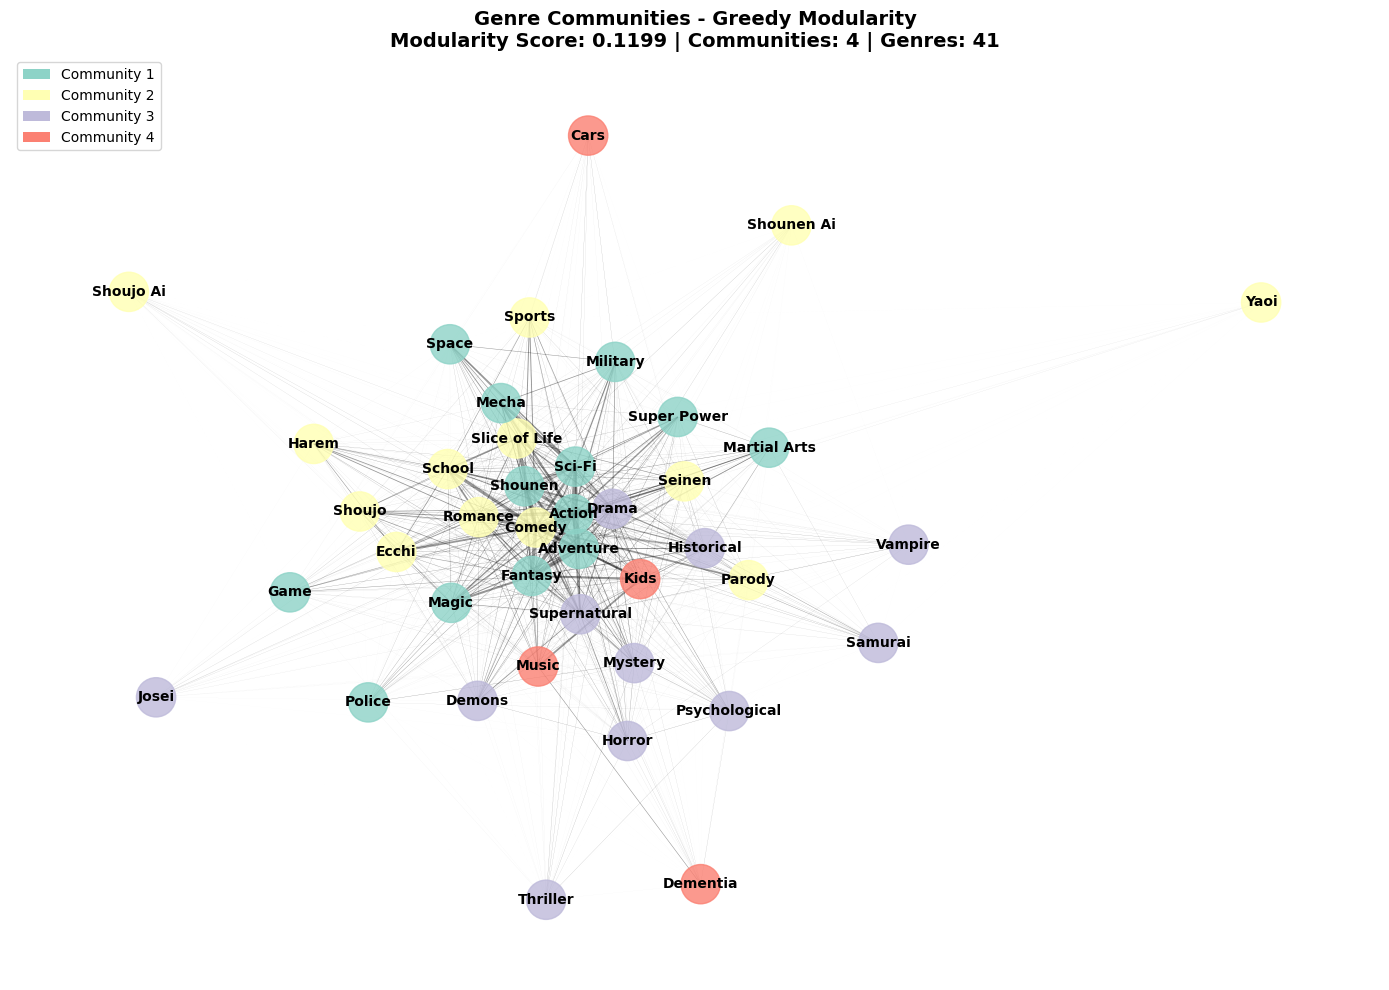

In [ ]:
#From copilot
def analyze_greedy_modularity(graph):
    """
    Run greedy modularity and explain what's happening
    """
    print("\n" + "="*70)
    print("GREEDY MODULARITY COMMUNITY DETECTION")
    print("="*70)

    # Step 1: Run the algorithm
    print("\n[STEP 1] Running the algorithm...")
    communities_list = list(community.greedy_modularity_communities(
        graph,
        weight='weight'
    ))

    # Step 2: Calculate modularity
    print("\n[STEP 2] Calculating modularity score...")
    modularity_score = community.modularity(
        graph,
        communities_list,
        weight='weight'
    )

    print(f"\n✓ Modularity Score: {modularity_score:.4f}")
    print(f"  (This measures how well the genres are grouped into communities)")

    # Step 3: Print basic stats
    print("\n[STEP 3] Basic Statistics")
    print("-" * 70)
    print(f"Total genres (nodes):     {graph.number_of_nodes()}")
    print(f"Total connections (edges): {graph.number_of_edges()}")
    print(f"Number of communities:    {len(communities_list)}")

    # Step 4: Detailed community information
    print("\n[STEP 4] Community Details")
    print("-" * 70)

    community_info = []
    for idx, community_set in enumerate(communities_list, 1):
        community_size = len(community_set)

        # Calculate edges within this community
        internal_edges = 0
        for node1 in community_set:
            for node2 in community_set:
                if node1 < node2 and graph.has_edge(node1, node2):
                    internal_edges += 1

        # Calculate edges going outside this community
        external_edges = 0
        for node in community_set:
            for neighbor in graph.neighbors(node):
                if neighbor not in community_set:
                    external_edges += 1

        community_info.append({
            'community_id': idx,
            'size': community_size,
            'genres': sorted(community_set),
            'internal_edges': internal_edges,
            'external_edges': external_edges,
            'density': internal_edges / (community_size * (community_size - 1) / 2) if community_size > 1 else 0
        })

        print(f"\n🎬 Community {idx}:")
        print(f"   Size: {community_size} genres")
        print(f"   Genres: {', '.join(sorted(community_set))}")
        print(f"   Internal edges: {internal_edges} (connections within community)")
        print(f"   External edges: {external_edges} (connections to other communities)")
        print(f"   Density: {community_info[-1]['density']:.4f} (how tightly connected)")

    # Step 5: Interpretation
    print("\n[STEP 5] What This Means")
    print("-" * 70)
    print("\nInternal Edges vs External Edges:")
    print("  - High internal edges = genres in community are strongly related")
    print("  - High external edges = community connects to other communities")
    print("\nDensity:")
    print("  - High density (close to 1) = all genres in community are connected")
    print("  - Low density (close to 0) = some genres aren't directly connected")

    return {
        'communities': communities_list,
        'modularity': modularity_score,
        'community_info': community_info
    }


def visualize_communities(graph, communities_list, modularity_score):
    """
    Visualize the communities with different colors
    """
    print("\n[STEP 6] Creating Visualization...")
    print("-" * 70)

    # Assign each node to a community number
    node_to_community = {}
    for idx, community_set in enumerate(communities_list):
        for node in community_set:
            node_to_community[node] = idx

    # Create a color map
    colors = plt.cm.Set3(range(len(communities_list)))
    node_colors = [colors[node_to_community[node]] for node in graph.nodes()]

    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 10))

    # Use spring layout for better visualization
    pos = nx.spring_layout(graph, k=2, iterations=50, seed=42, weight='weight')

    # Draw the network
    nx.draw_networkx_nodes(
        graph, pos,
        node_color=node_colors,
        node_size=800,
        ax=ax,
        alpha=0.8
    )

    # Draw edges (thicker edges = stronger connection)
    edges = graph.edges()
    weights = [graph[u][v]['weight'] for u, v in edges]
    max_weight = max(weights)

    nx.draw_networkx_edges(
        graph, pos,
        width=[3 * w / max_weight for w in weights],
        alpha=0.4,
        ax=ax
    )

    # Draw labels
    nx.draw_networkx_labels(graph, pos, font_size=10, font_weight='bold', ax=ax)

    # Title and info
    ax.set_title(
        f'Genre Communities - Greedy Modularity\n'
        f'Modularity Score: {modularity_score:.4f} | '
        f'Communities: {len(communities_list)} | '
        f'Genres: {graph.number_of_nodes()}',
        fontsize=14,
        fontweight='bold'
    )
    ax.axis('off')

    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[i], label=f'Community {i+1}')
        for i in range(len(communities_list))
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.savefig('greedy_modularity_communities.png', dpi=300, bbox_inches='tight')
    print("\n✓ Visualization saved as 'greedy_modularity_communities.png'")
    plt.show()

# Run the analysis
results = analyze_greedy_modularity(Genres)

# Visualize
visualize_communities(Genres, results['communities'], results['modularity'])


*Some thoughts*

Right off the bat this has a very low modularity score of 0.1 which tells us that all the genres are very interconnected - which we knew already.

Looking at each community, here are the community themes extracted by copilot:

**Community 1: Action and Adventure Core**

Characteristics:

* Largest action-oriented cluster
* High density (1.0) = every genre connects to every other genre
78 internal edges vs 330 external edges
* Interpretation: These are the "explosive, high-energy" anime genres. They strongly connect to each other (which is why density is perfect), but they also heavily cross into other genres.

*My interpretation: I would say this is the most generic community it groups together too many very broad genres, like action, adventure, fantasy which explains why there are also so many external edges to other communties*

**Community 2: Romance and Slice of Life**

Characteristics:

* Character/relationship focused
* Density 0.8590 = very connected (only 1 missing edge)
* 67 internal edges vs 311 external edges
* Interpretation: The "softer" genres. School settings, romance, comedy, and relationship-driven content cluster here. Still heavily bridged to other communities.

*My interpretation: I actually think this is a pretty good grouping and a good interpretation by copilot - comedy, romance and slice of life do typically go hand in hand and feature more character driven stories than that of community one (as a genralisation). HOWEVER, seinen really should not be in this group and I would also say the same about sport*

**Community 3: Dark & Psychological**

Characteristics:

* Mature/darker themes
* Density 0.9455 = highly connected
52 internal edges vs 285 external edges
* Interpretation: Serious, dark, and mature genres. These tend to cluster together (demons, horror, psychological), but still bridge heavily to drama and historical content.

*My interpretation: Again I would say this is a pretty good grouping and theme matching, but once again we have an outlier in josei, feels like it would be better suited for community 3*

**Community 4: Niche Genres**

Characteristics:

Problematic cluster - these are outliers!
Density 1.0 but only 6 internal edges (very small)
120 external edges (huge proportion for just 4 nodes)
Interpretation: These genres don't naturally fit with others. They're isolated outliers that the algorithm grouped together by default.

*My interpretation: I would not necessarily say these are problematic, just odd. I think it would be better to keep them in to show they full range of diversity among the genres. I think they stand out because they are so specific but I think they would fit well into the other communities as opposed to being on their own. But still having them as their own niche community also makes sense*

# 2. Louvain Algorithm CHOSEN

It uses the louvain method described in Fast unfolding of communities in large networks, Vincent D Blondel, Jean-Loup Guillaume, Renaud Lambiotte, Renaud Lefebvre, Journal of Statistical Mechanics: Theory and Experiment 2008(10), P10008 (12pp)

Source: https://python-louvain.readthedocs.io/en/latest/

From copilot:

WHAT IS THE LOUVAIN ALGORITHM?

The Louvain method is one of the most popular algorithms for community detection
because it's fast AND produces very high quality results.

KEY DIFFERENCE FROM GREEDY MODULARITY:
- Greedy Modularity: Merges communities from bottom-up
- Louvain: Uses a MULTI-LEVEL approach with optimization

HOW LOUVAIN WORKS (Simplified):

The algorithm has TWO PHASES that repeat until no improvement:

PHASE 1: LOCAL OPTIMIZATION
- For each node, try moving it to neighboring communities
- Move the node if it INCREASES modularity
- Repeat for all nodes until no more moves increase modularity
- Result: Communities start forming locally

PHASE 2: AGGREGATION (Pooling)
- Treat each community as a single "super-node"
- Create a new network where super-nodes are the new nodes
- Connect super-nodes if their original communities connected
- Go back to PHASE 1 on this new network

WHY IS THIS BETTER?
- It finds local optima efficiently
- The multi-level approach helps avoid getting stuck
- Can detect communities at different scales
- Often produces higher modularity than greedy methods

ANALOGY:

Think of it like organizing a messy room:
1. First pass: Move items into rough areas (Local Optimization)
2. Reorganize: Group the rough areas into sections (Aggregation)
3. Refine: Move items between sections if it improves organization
4. Repeat steps 1-3 until the room looks good

In [ ]:
pip install python-louvain

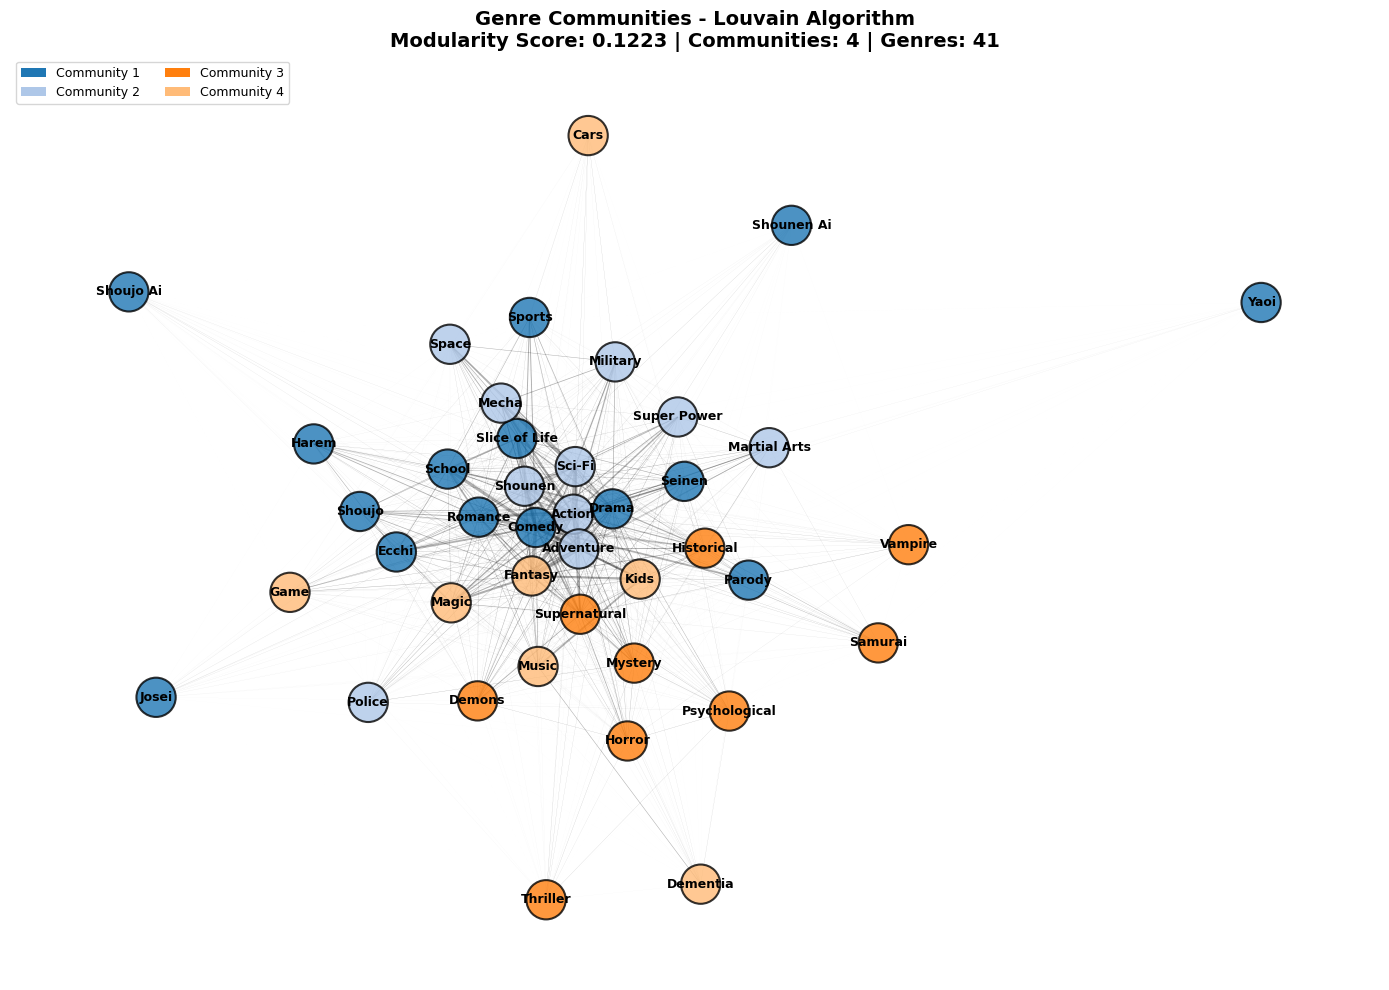


LOUVAIN COMMUNITY DETECTION

[STEP 1] Running the algorithm...

[STEP 2] Calculating modularity score...

✓ Modularity Score: 0.1223

[STEP 3] Basic Statistics
----------------------------------------------------------------------
Total genres (nodes):     41
Total connections (edges): 726
Number of communities:    4

[STEP 4] Community Details
----------------------------------------------------------------------

🎬 Community 2:
   Size: 15 genres
   Genres: Comedy, Drama, Ecchi, Harem, Josei, Parody, Romance, School, Seinen, Shoujo, Shoujo Ai, Shounen Ai, Slice of Life, Sports, Yaoi
   Internal edges: 89 (connections within community)
   External edges: 333 (connections to other communities)
   Density: 0.8476 (how tightly connected)

🎬 Community 1:
   Size: 10 genres
   Genres: Action, Adventure, Martial Arts, Mecha, Military, Police, Sci-Fi, Shounen, Space, Super Power
   Internal edges: 45 (connections within community)
   External edges: 282 (connections to other communities)
  

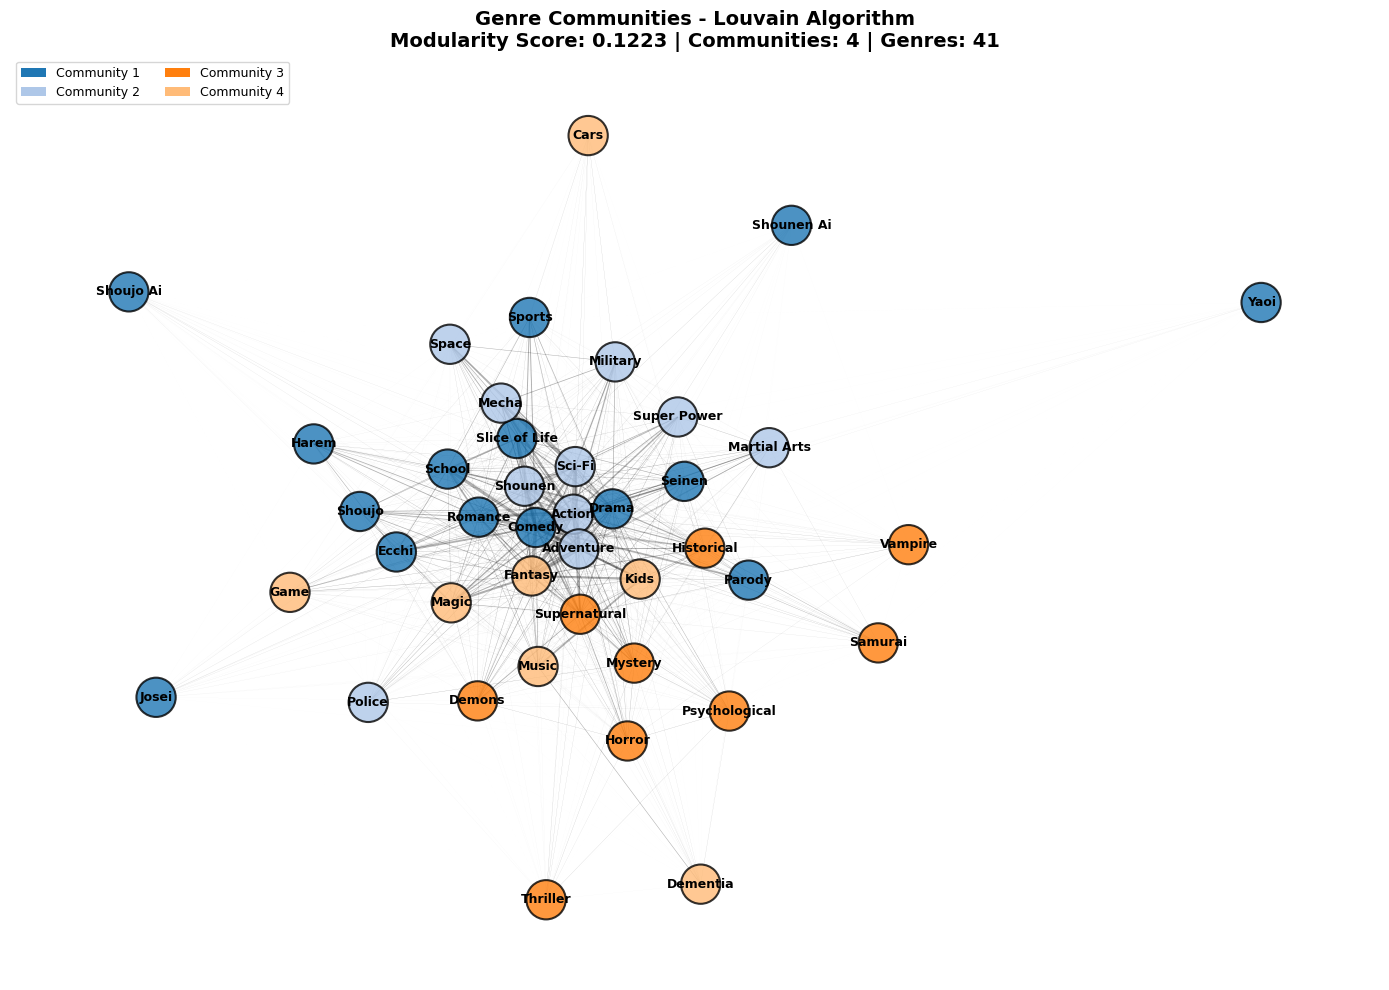

In [ ]:
#from copilot
from collections import defaultdict
def analyze_louvain_algorithm(graph):
    """
    Run Louvain algorithm and display results
    """
    try:
        from community import community_louvain
    except ImportError:
        print("\n" + "!"*70)
        print("ERROR: python-louvain package not installed")
        print("!"*70)
        print("\nTo install, run:")
        print("  pip install python-louvain")
        print("!"*70)
        return None

    print("\n" + "="*70)
    print("LOUVAIN COMMUNITY DETECTION")
    print("="*70)

    # Run algorithm
    print("\n[STEP 1] Running the algorithm...")
    import time
    start_time = time.time()

    partition = community_louvain.best_partition(
        graph,
        weight='weight',
        randomize=None,
        random_state=42
    )

    elapsed_time = time.time() - start_time

    # Convert partition to communities
    print("\n[STEP 2] Calculating modularity score...")

    communities_dict = defaultdict(list)
    for node, community_id in partition.items():
        communities_dict[community_id].append(node)

    communities_list = list(communities_dict.values())

    modularity_score = community_louvain.modularity(
        partition,
        graph,
        weight='weight'
    )

    print(f"\n✓ Modularity Score: {modularity_score:.4f}")

    # Basic stats
    print("\n[STEP 3] Basic Statistics")
    print("-" * 70)
    print(f"Total genres (nodes):     {graph.number_of_nodes()}")
    print(f"Total connections (edges): {graph.number_of_edges()}")
    print(f"Number of communities:    {len(communities_list)}")

        # Community details
    print("\n[STEP 4] Community Details")
    print("-" * 70)

    community_info = []

    # Sort communities by size
    sorted_communities = sorted(
        enumerate(communities_list),
        key=lambda x: len(x[1]),
        reverse=True
    )

    for idx, community_set in sorted_communities:
        community_size = len(community_set)

        # Calculate internal edges
        internal_edges = 0
        for node1 in community_set:
            for node2 in community_set:
                if node1 < node2 and graph.has_edge(node1, node2):
                    internal_edges += 1

        # Calculate external edges
        external_edges = 0
        for node in community_set:
            for neighbor in graph.neighbors(node):
                if neighbor not in community_set:
                    external_edges += 1

        # Density
        max_possible_edges = community_size * (community_size - 1) / 2
        density = internal_edges / max_possible_edges if community_size > 1 else 0

        community_info.append({
            'id': idx,
            'size': community_size,
            'genres': sorted(community_set),
            'internal_edges': internal_edges,
            'external_edges': external_edges,
            'density': density
        })

        print(f"\n🎬 Community {idx + 1}:")
        print(f"   Size: {community_size} genres")
        print(f"   Genres: {', '.join(sorted(community_set))}")
        print(f"   Internal edges: {internal_edges} (connections within community)")
        print(f"   External edges: {external_edges} (connections to other communities)")
        print(f"   Density: {density:.4f} (how tightly connected)")

    return {
        'partition': partition,
        'communities': communities_list,
        'modularity': modularity_score,
        'community_info': community_info,
        'time': elapsed_time
    }


def compare_algorithms(louvain_results):
    """
    Compare Louvain with Greedy Modularity results
    """
    print("\n[STEP 5] Comparison: Louvain vs Greedy Modularity")
    print("-" * 70)

    # Hardcoded Greedy results from your output
    greedy_modularity = 0.1199
    greedy_communities = 4
    louvain_modularity = louvain_results['modularity']
    louvain_communities = len(louvain_results['communities'])

    print(f"\n{'Metric':<30} {'Greedy Modularity':<20} {'Louvain':<20}")
    print("-" * 70)
    print(f"{'Modularity Score':<30} {greedy_modularity:<20.4f} {louvain_modularity:<20.4f}")
    print(f"{'Number of Communities':<30} {greedy_communities:<20} {louvain_communities:<20}")

    improvement = ((louvain_modularity - greedy_modularity) / greedy_modularity) * 100

    print(f"\n📊 Analysis:")
    if improvement > 5:
        print(f"   ✓ Louvain improved modularity by {improvement:.1f}%")
        print(f"   → RECOMMEND: Use Louvain")
    elif improvement < -5:
        print(f"   • Greedy Modularity was {-improvement:.1f}% better")
        print(f"   → RECOMMEND: Use Greedy Modularity")
    else:
        print(f"   • Both algorithms performed similarly")
        print(f"   → Either works, but Louvain is more robust")


def visualize_louvain_communities(graph, partition, modularity_score):
    """
    Visualize the Louvain communities
    """
    print("\n[STEP 6] Creating Visualization...")

    # Convert partition to communities
    communities_dict = defaultdict(list)
    for node, community_id in partition.items():
        communities_dict[community_id].append(node)

    communities_list = list(communities_dict.values())

    # Create colors
    colors = plt.cm.tab20(range(len(communities_list)))

    # Map nodes to community colors
    node_to_community = {node: idx for idx, (_, nodes) in enumerate(sorted(
        communities_dict.items(),
        key=lambda x: len(x[1]),
        reverse=True
    )) for node in nodes}

    node_colors = [colors[node_to_community[node]] for node in graph.nodes()]

    # Create plot
    fig, ax = plt.subplots(figsize=(14, 10))

    # Layout
    pos = nx.spring_layout(graph, k=2, iterations=50, seed=42, weight='weight')

    # Draw nodes
    nx.draw_networkx_nodes(
        graph, pos,
        node_color=node_colors,
        node_size=800,
        ax=ax,
        alpha=0.8,
        edgecolors='black',
        linewidths=1.5
    )

    # Draw edges
    edges = graph.edges()
    weights = [graph[u][v]['weight'] for u, v in edges]
    max_weight = max(weights)

    nx.draw_networkx_edges(
        graph, pos,
        width=[3 * w / max_weight for w in weights],
        alpha=0.3,
        ax=ax
    )

    # Labels
    nx.draw_networkx_labels(graph, pos, font_size=9, font_weight='bold', ax=ax)

    # Title
    ax.set_title(
        f'Genre Communities - Louvain Algorithm\n'
        f'Modularity Score: {modularity_score:.4f} | '
        f'Communities: {len(communities_list)} | '
        f'Genres: {graph.number_of_nodes()}',
        fontsize=14,
        fontweight='bold'
    )
    ax.axis('off')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[i], label=f'Community {i+1}')
        for i in range(len(communities_list))
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9, ncol=2)

    plt.tight_layout()
    plt.savefig('louvain_communities.png', dpi=300, bbox_inches='tight')
    print("✓ Visualization saved as 'louvain_communities.png'")
    plt.show()

# Using your Genres graph
genre_comms = analyze_louvain_algorithm(Genres)

# Compare with your Greedy Modularity results
compare_algorithms(genre_comms)

# Visualize the communities
visualize_louvain_communities(Genres, genre_comms['partition'], genre_comms['modularity'])


# 3. Label Propergation Algorithm

Finds communities in G using a semi-synchronous label propagation method. This method combines the advantages of both the synchronous and asynchronous models.

Source: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.label_propagation.label_propagation_communities.html

In [ ]:
import networkx as nx
from networkx.algorithms import community
from collections import defaultdict
import matplotlib.pyplot as plt

"""
WHAT IS LABEL PROPAGATION?
--------------------------
Label Propagation is a simple and fast community detection algorithm.

HOW IT WORKS:
1. Start: Each node gets a unique label (community ID)
2. Iterate: Each node adopts the most common label among its neighbors
3. Stop: When labels stabilize (no changes in an iteration)

KEY CHARACTERISTIC:
- It's RANDOMIZED - different runs may give different results
- Very fast O(n) complexity
- Good for exploring different community structures
- Less deterministic than Louvain or Greedy

WHY TRY IT:
- Might find different structure we missed
- Can provide alternative perspective
- Good validation tool
"""

def analyze_label_propagation(graph, num_runs=5):
    """
    Run Label Propagation multiple times (since it's randomized)
    and show best result
    """
    print("\n" + "="*70)
    print("LABEL PROPAGATION COMMUNITY DETECTION")
    print("="*70)

    print("\n[STEP 1] Running algorithm (multiple times since it's randomized)...")

    best_modularity = -1
    best_communities = None
    all_results = []

    for run in range(num_runs):
        communities_list = list(community.label_propagation_communities(graph))
        modularity = community.modularity(graph, communities_list, weight='weight')

        all_results.append({
            'run': run + 1,
            'communities': communities_list,
            'modularity': modularity,
            'num_communities': len(communities_list)
        })

        print(f"  Run {run + 1}: Modularity = {modularity:.4f}, Communities = {len(communities_list)}")

        if modularity > best_modularity:
            best_modularity = modularity
            best_communities = communities_list

    print(f"\n✓ Best result from {num_runs} runs:")
    print(f"  Modularity Score: {best_modularity:.4f}")

    # Basic stats
    print("\n[STEP 2] Basic Statistics")
    print("-" * 70)
    print(f"Total genres (nodes):     {graph.number_of_nodes()}")
    print(f"Total connections (edges): {graph.number_of_edges()}")
    print(f"Number of communities:    {len(best_communities)}")

    # Community details
    print("\n[STEP 3] Community Details")
    print("-" * 70)

    sorted_communities = sorted(
        enumerate(best_communities),
        key=lambda x: len(x[1]),
        reverse=True
    )

    for idx, community_set in sorted_communities:
        community_size = len(community_set)

        # Calculate internal edges
        internal_edges = 0
        for node1 in community_set:
            for node2 in community_set:
                if node1 < node2 and graph.has_edge(node1, node2):
                    internal_edges += 1

        # Calculate external edges
        external_edges = 0
        for node in community_set:
            for neighbor in graph.neighbors(node):
                if neighbor not in community_set:
                    external_edges += 1

        # Density
        max_possible_edges = community_size * (community_size - 1) / 2
        density = internal_edges / max_possible_edges if community_size > 1 else 0

        print(f"\n🎬 Community {idx + 1}:")
        print(f"   Size: {community_size} genres")
        print(f"   Genres: {', '.join(sorted(community_set))}")
        print(f"   Internal edges: {internal_edges}")
        print(f"   External edges: {external_edges}")
        print(f"   Density: {density:.4f}")

    return {
        'communities': best_communities,
        'modularity': best_modularity,
        'all_runs': all_results
    }


def compare_all_three(label_prop_results):
    """
    Compare Label Propagation with Louvain and Greedy Modularity
    """
    print("\n[STEP 4] Comparison: All Three Algorithms")
    print("-" * 70)

    greedy_modularity = 0.1199
    greedy_communities = 4
    louvain_modularity = 0.1223
    louvain_communities = 4
    lp_modularity = label_prop_results['modularity']
    lp_communities = len(label_prop_results['communities'])

    print(f"\n{'Metric':<30} {'Greedy':<15} {'Louvain':<15} {'Label Prop':<15}")
    print("-" * 70)
    print(f"{'Modularity Score':<30} {greedy_modularity:<15.4f} {louvain_modularity:<15.4f} {lp_modularity:<15.4f}")
    print(f"{'Number of Communities':<30} {greedy_communities:<15} {louvain_communities:<15} {lp_communities:<15}")

    # Find best
    scores = {
        'Greedy': greedy_modularity,
        'Louvain': louvain_modularity,
        'Label Propagation': lp_modularity
    }

    best_algo = max(scores, key=scores.get)
    best_score = scores[best_algo]

    print(f"\n🏆 Best Algorithm: {best_algo}")
    print(f"   Modularity: {best_score:.4f}")

    # Calculate improvements
    lp_vs_greedy = ((lp_modularity - greedy_modularity) / greedy_modularity) * 100
    lp_vs_louvain = ((lp_modularity - louvain_modularity) / louvain_modularity) * 100

    print(f"\n📊 Label Propagation vs others:")
    print(f"   vs Greedy: {lp_vs_greedy:+.2f}%")
    print(f"   vs Louvain: {lp_vs_louvain:+.2f}%")

# Run Label Propagation (5 times since it's randomized)
lp_results = analyze_label_propagation(Genres, num_runs=5)

# Compare with Louvain and Greedy
compare_all_three(lp_results)


LABEL PROPAGATION COMMUNITY DETECTION

[STEP 1] Running algorithm (multiple times since it's randomized)...
  Run 1: Modularity = 0.0000, Communities = 1
  Run 2: Modularity = 0.0000, Communities = 1
  Run 3: Modularity = 0.0000, Communities = 1
  Run 4: Modularity = 0.0000, Communities = 1
  Run 5: Modularity = 0.0000, Communities = 1

✓ Best result from 5 runs:
  Modularity Score: 0.0000

[STEP 2] Basic Statistics
----------------------------------------------------------------------
Total genres (nodes):     41
Total connections (edges): 726
Number of communities:    1

[STEP 3] Community Details
----------------------------------------------------------------------

🎬 Community 1:
   Size: 41 genres
   Genres: Action, Adventure, Cars, Comedy, Dementia, Demons, Drama, Ecchi, Fantasy, Game, Harem, Historical, Horror, Josei, Kids, Magic, Martial Arts, Mecha, Military, Music, Mystery, Parody, Police, Psychological, Romance, Samurai, School, Sci-Fi, Seinen, Shoujo, Shoujo Ai, Shounen, 

# **Mapping Anime to Genre Communities**

Now that we have found our communities, based on the lauvain algorithm, we can associate each anime in our dataset to a corresponding community.

Things to consider:

- should we only do one community per anime
- or can it be that an anime could belong to more than one community
- how would this decision affect the user connections?

In [ ]:
# From copilot
import pandas as pd
"""
PHASE 2 OVERVIEW:
-----------------
Goal: Map each anime to the most appropriate genre community

For each anime:
1. Extract its genres
2. Count how many genres belong to each community
3. Assign anime to the community with the most genres
4. Calculate confidence score (what % of anime's genres are in that community)
5. Handle "bridge" anime (those with genres spanning multiple communities)
"""

def create_genre_to_community_mapping(louvain_communities):
    """
    [STEP 1] Create a lookup dictionary: genre -> community_id

    This makes it fast to look up which community a genre belongs to.

    Input: List of communities (each community is a list of genres)
    Output: Dictionary mapping each genre to its community ID
    """
    print("\n" + "="*70)
    print("PHASE 2: ASSIGNING ANIME TO GENRE COMMUNITIES")
    print("="*70)

    print("\n[STEP 1] Creating Genre-to-Community Mapping...")
    print("-" * 70)

    genre_to_community = {}

    # For each community, map all its genres to the community ID
    for community_id, community_genres in enumerate(louvain_communities, 1):
        for genre in community_genres:
            genre_to_community[genre] = community_id

    print(f"\n✓ Mapping created for {len(genre_to_community)} genres")
    print(f"✓ Total communities: {len(louvain_communities)}")

    # Display the mapping
    print("\nGenre to Community Mapping:")
    for community_id, community_genres in enumerate(louvain_communities, 1):
        print(f"\n  Community {community_id}: ({len(community_genres)} genres)")
        print(f"    {', '.join(sorted(community_genres))}")

    return genre_to_community, louvain_communities


def assign_anime_to_communities(anime_df, genre_to_community, louvain_communities):
    """
    [STEP 2] Assign each anime to its best-matching community

    For each anime:
    - Extract its genres
    - Count how many genres belong to each community
    - Assign to the community with the most genres
    - Calculate confidence (% of genres in that community)
    """
    print("\n[STEP 2] Assigning Anime to Communities...")
    print("-" * 70)

    # Initialize lists to store results
    anime_assignments = []

    # Process each anime
    total_anime = len(anime_df)
    print(f"\nProcessing {total_anime} anime...")

    for idx, row in anime_df.iterrows():
        # Extract genres from the anime
        # Handle different possible column names and formats
        if 'Genres' in row:
            genres_str = row['Genres']
        elif 'genre' in row:
            genres_str = row['genre']
        else:
            continue

        # Skip if no genres listed
        if pd.isna(genres_str):
            continue

        # Parse genres (assuming they're comma-separated)
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]

        if not genres:
            continue

        # [STEP 2A] Count genres in each community
        community_counts = defaultdict(int)
        for genre in genres:
            if genre in genre_to_community:
                community_id = genre_to_community[genre]
                community_counts[community_id] += 1

        # [STEP 2B] Assign to community with most genres
        if community_counts:
            # Find the community with the highest count
            assigned_community = max(community_counts, key=community_counts.get)
            count_in_community = community_counts[assigned_community]

            # [STEP 2C] Calculate confidence score
            # Confidence = (genres in assigned community) / (total genres)
            confidence = count_in_community / len(genres)

            # [STEP 2D] Count how many communities this anime spans
            num_communities_spanned = len(community_counts)

            # [STEP 2E] Identify if anime is a "bridge" (spans multiple communities)
            is_bridge = num_communities_spanned > 1

            # Store the assignment
            anime_assignments.append({
                'anime_id': row["MAL_ID"],
                'anime_name': row.get('Name', row.get('name', f'Anime_{idx}')),
                'genres': ', '.join(genres),
                'num_genres': len(genres),
                'assigned_community': assigned_community,
                'confidence': confidence,
                'communities_spanned': num_communities_spanned,
                'is_bridge': is_bridge,
                'community_distribution': dict(community_counts)
            })

        # Progress indicator
        if (idx + 1) % max(1, total_anime // 10) == 0:
            print(f"  Processed {idx + 1}/{total_anime} anime...")

    # Create DataFrame from assignments
    assignments_df = pd.DataFrame(anime_assignments)

    print(f"\n✓ Assignment complete!")
    print(f"  Total anime assigned: {len(assignments_df)}")

    return assignments_df


def analyze_assignments(assignments_df, louvain_communities):
    """
    [STEP 3] Analyze the anime assignments

    Show statistics about:
    - How many anime in each community
    - Confidence scores (how well anime match their communities)
    - Bridge anime (anime spanning multiple communities)
    """
    print("\n[STEP 3] Assignment Statistics")
    print("-" * 70)

    # [STEP 3A] Count anime per community
    print("\nAnime per Community:")
    community_counts = assignments_df['assigned_community'].value_counts().sort_index()

    for community_id, count in community_counts.items():
        percentage = (count / len(assignments_df)) * 100
        num_genres = len(louvain_communities[community_id-1])
        print(f"\n  Community {community_id}: {count} anime ({percentage:.1f}%)")
        print(f"    Contains {num_genres} genres: {', '.join(louvain_communities[community_id-1])}")

    # [STEP 3B] Confidence score statistics
    print("\n" + "-" * 70)
    print("Confidence Score Statistics:")
    print(f"  Mean confidence: {assignments_df['confidence'].mean():.4f}")
    print(f"  Median confidence: {assignments_df['confidence'].median():.4f}")
    print(f"  Min confidence: {assignments_df['confidence'].min():.4f}")
    print(f"  Max confidence: {assignments_df['confidence'].max():.4f}")

    # [STEP 3C] Bridge anime statistics
    print("\n" + "-" * 70)
    print("Bridge Anime (Spanning Multiple Communities):")
    bridge_anime = assignments_df[assignments_df['is_bridge']]
    print(f"  Total bridge anime: {len(bridge_anime)} ({(len(bridge_anime)/len(assignments_df))*100:.1f}%)")

    # Show distribution of how many communities they span
    span_distribution = bridge_anime['communities_spanned'].value_counts().sort_index()
    for num_communities, count in span_distribution.items():
        print(f"    Spanning {num_communities} communities: {count} anime")

    # [STEP 3D] Low confidence anime (might be misassigned)
    print("\n" + "-" * 70)
    print("Low Confidence Anime (confidence < 0.5):")
    low_conf = assignments_df[assignments_df['confidence'] < 0.5]
    print(f"  Total: {len(low_conf)} anime ({(len(low_conf)/len(assignments_df))*100:.1f}%)")

    if len(low_conf) > 0:
        print("\n  Examples:")
        for idx, row in low_conf.head(10).iterrows():
            print(f"    - {row['anime_name']}: {row['genres']}")
            print(f"      Assigned to Community {row['assigned_community']} (confidence: {row['confidence']:.2f})")


def create_summary_table(assignments_df, louvain_communities):
    """
    [STEP 4] Create a summary table

    Shows a clean table with all anime assignments
    """
    print("\n[STEP 4] Creating Summary Table")
    print("-" * 70)

    # Create community name mapping for readability
    community_names = {
        1: "Action & Adventure",
        2: "Romance & Slice of Life",
        3: "Dark & Psychological",
        4: "Niche & Fantasy"
    }

    # Add community name column
    assignments_df['community_name'] = assignments_df['assigned_community'].map(
        lambda x: community_names.get(x, f"Community {x}")
    )

    # Create a display table
    display_df = assignments_df[[
        'anime_name',
        'num_genres',
        'assigned_community',
        'community_name',
        'confidence',
        'is_bridge'
    ]].copy()

    display_df.columns = [
        'Anime Name',
        'Num Genres',
        'Community ID',
        'Community Name',
        'Confidence',
        'Is Bridge'
    ]

    print(f"\nFirst 20 anime assignments:")
    print(display_df.head(20).to_string(index=False))

    print(f"\n... ({len(display_df)} total anime)")

    return assignments_df


def save_assignments(assignments_df, output_file='anime_community_assignments.csv'):
    """
    [STEP 5] Save assignments to CSV for later use

    This creates a file you can use in Phase 3 for user analysis
    """
    print("\n[STEP 5] Saving Results")
    print("-" * 70)

    # Save to CSV
    assignments_df.to_csv(output_file, index=False)
    print(f"\n✓ Assignments saved to: {output_file}")
    print(f"  Total records: {len(assignments_df)}")

    return assignments_df


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_phase2(anime_df, louvain_communities):
    """
    Run the complete Phase 2 pipeline

    Input:
    - anime_df: DataFrame with anime data (must have 'Genres' or 'genre' column)
    - louvain_communities: List of communities from Phase 1

    Output:
    - assignments_df: DataFrame with anime-to-community assignments
    """

    # Step 1: Create genre to community mapping
    genre_to_community, communities = create_genre_to_community_mapping(louvain_communities)

    # Step 2: Assign anime to communities
    assignments_df = assign_anime_to_communities(anime_df, genre_to_community, communities)

    # Step 3: Analyze assignments
    analyze_assignments(assignments_df, communities)

    # Step 4: Create summary table
    assignments_df = create_summary_table(assignments_df, communities)

    # Step 5: Save results
    assignments_df = save_assignments(assignments_df)

    print("\n" + "="*70)
    print("✓ PHASE 2 COMPLETE!")
    print("="*70)
    print("\nNext: Phase 3 - User Behavior Analysis")
    print("We'll analyze how users interact with different communities")

    return assignments_df

# Run Phase 2
animeGenreComs_df = run_phase2(animelist_synoposis, results['communities'])


PHASE 2: ASSIGNING ANIME TO GENRE COMMUNITIES

[STEP 1] Creating Genre-to-Community Mapping...
----------------------------------------------------------------------

✓ Mapping created for 41 genres
✓ Total communities: 4

Genre to Community Mapping:

  Community 1: (13 genres)
    Action, Adventure, Fantasy, Game, Magic, Martial Arts, Mecha, Military, Police, Sci-Fi, Shounen, Space, Super Power

  Community 2: (13 genres)
    Comedy, Ecchi, Harem, Parody, Romance, School, Seinen, Shoujo, Shoujo Ai, Shounen Ai, Slice of Life, Sports, Yaoi

  Community 3: (11 genres)
    Demons, Drama, Historical, Horror, Josei, Mystery, Psychological, Samurai, Supernatural, Thriller, Vampire

  Community 4: (4 genres)
    Cars, Dementia, Kids, Music

[STEP 2] Assigning Anime to Communities...
----------------------------------------------------------------------

Processing 16214 anime...
  Processed 1621/16214 anime...
  Processed 3242/16214 anime...
  Processed 4863/16214 anime...
  Processed 6484/1

*Some reflections*

working with the current genre communties we got from the louvain algorithm has its pros and cons.

For one, the genres were divided into pretty evenly grouped communities which has also allowed the anime to be spread across the community fairly evenly. The action adventure community and the comedy romance community are pretty evenly split with roughly 31% and 37% of the anime which does feel reflective of anime trends in general.

The smallest community is the dark and psychological with only 6% of the anime but this number translates to roughly 1000 anime which is still a decent amount. And the niche genre having 24% of the anime may be due to the varied types of genre within that community.

Because while the communities are helpful for now, and definitely a good starting point, they are no where near perfect. The large size of the first and second community for example means that an anime like evangelion will be in the same community as Mahou Shoujo Lyrical Nanoha A's which I more instictively put that with the other shojou anime.

But this is also due to the nature of the genre tags not having any real way to measure their importance in an anime.

In terms of "bridge anime" - it appears that there are about 600 non bridge anime and the rest are bridge. Which basically means there are about 600 anime with only one genre. Which does not tell us much.

I think we should redefine what a bridge anime is so we can more clearly highlight overlaps between the communities. For example we could define a bridge anime as that which has an equal number of genres from multiple communities.

(Also in terms of networks I think we called call this a bipartite network of anime and genre communities and if we could weight the connections based on the community distribution of the genre in each anime - something to think about)

*actually lets test that out*

In [ ]:
import pandas as pd
from collections import defaultdict

# ============================================================================
# PHASE 2: ASSIGNING ANIME TO GENRE COMMUNITIES (REVISED)
# ============================================================================

"""
PHASE 2 OVERVIEW (REVISED):
-----------------
Goal: Map each anime to the most appropriate genre community

For each anime:
1. Extract its genres
2. Count how many genres belong to each community
3. Check if distribution is EQUAL across communities
   - If equal: anime is a bridge (assigned to multiple communities)
   - If not equal: assign to community with most genres
4. Calculate confidence score
5. Handle multi-community assignments
"""

def create_genre_to_community_mapping(louvain_communities):
    """
    [STEP 1] Create a lookup dictionary: genre -> community_id

    This makes it fast to look up which community a genre belongs to.

    Input: List of communities (each community is a list of genres)
    Output: Dictionary mapping each genre to its community ID
    """
    print("\n" + "="*70)
    print("PHASE 2: ASSIGNING ANIME TO GENRE COMMUNITIES")
    print("="*70)

    print("\n[STEP 1] Creating Genre-to-Community Mapping...")
    print("-" * 70)

    genre_to_community = {}

    # For each community, map all its genres to the community ID
    for community_id, community_genres in enumerate(louvain_communities, 1):
        for genre in community_genres:
            genre_to_community[genre] = community_id

    print(f"\n✓ Mapping created for {len(genre_to_community)} genres")
    print(f"✓ Total communities: {len(louvain_communities)}")

    # Display the mapping
    print("\nGenre to Community Mapping:")
    for community_id, community_genres in enumerate(louvain_communities, 1):
        print(f"\n  Community {community_id}: ({len(community_genres)} genres)")
        print(f"    {', '.join(sorted(community_genres))}")

    return genre_to_community, louvain_communities


def assign_anime_to_communities(anime_df, genre_to_community, louvain_communities):
    """
    [STEP 2] Assign each anime to its best-matching community

    For each anime:
    - Extract its genres
    - Count how many genres belong to each community
    - Check if distribution is EQUAL across all communities
    - If equal: assign to all those communities (bridge anime)
    - If not equal: assign to the community with most genres
    - Calculate confidence (% of genres in assigned communities)
    """
    print("\n[STEP 2] Assigning Anime to Communities...")
    print("-" * 70)

    # Initialize lists to store results
    anime_assignments = []

    # Process each anime
    total_anime = len(anime_df)
    print(f"\nProcessing {total_anime} anime...")

    for idx, row in anime_df.iterrows():
        # Extract genres from the anime
        # Handle different possible column names and formats
        if 'Genres' in row:
            genres_str = row['Genres']
        elif 'genre' in row:
            genres_str = row['genre']
        else:
            continue

        # Skip if no genres listed
        if pd.isna(genres_str):
            continue

        # Parse genres (assuming they're comma-separated)
        genres = [g.strip() for g in str(genres_str).split(',') if g.strip()]

        if not genres:
            continue

        # [STEP 2A] Count genres in each community
        community_counts = defaultdict(int)
        for genre in genres:
            if genre in genre_to_community:
                community_id = genre_to_community[genre]
                community_counts[community_id] += 1

        # [STEP 2B] Check if distribution is equal across communities
        if community_counts:
            # Check if all communities have equal genre counts
            counts_list = list(community_counts.values())
            is_equal_distribution = len(set(counts_list)) == 1 and len(community_counts) > 1

            if is_equal_distribution:
                # Equal distribution: assign to all communities (true bridge)
                assigned_communities = sorted(list(community_counts.keys()))
                count_in_community = community_counts[assigned_communities[0]]
                confidence = count_in_community / len(genres)

                # Create a single record for the bridge anime with all assigned communities
                anime_assignments.append({
                    'anime_id': row["MAL_ID"],
                    'anime_name': row.get('Name', row.get('name', f'Anime_{idx}')),
                    'genres': ', '.join(genres),
                    'num_genres': len(genres),
                    'assigned_communities': assigned_communities,
                    'confidence': confidence,
                    'communities_spanned': len(community_counts),
                    'is_bridge': True,
                    'community_distribution': dict(community_counts)
                })
            else:
                # Unequal distribution: assign to community with most genres
                assigned_community = max(community_counts, key=community_counts.get)
                count_in_community = community_counts[assigned_community]

                # [STEP 2C] Calculate confidence score
                # Confidence = (genres in assigned community) / (total genres)
                confidence = count_in_community / len(genres)

                # [STEP 2D] Count how many communities this anime spans
                num_communities_spanned = len(community_counts)

                # [STEP 2E] Identify if anime is a "bridge" (equal distribution only)
                is_bridge = False

                # Store the assignment
                anime_assignments.append({
                    'anime_id': row["MAL_ID"],
                    'anime_name': row.get('Name', row.get('name', f'Anime_{idx}')),
                    'genres': ', '.join(genres),
                    'num_genres': len(genres),
                    'assigned_communities': [assigned_community],
                    'confidence': confidence,
                    'communities_spanned': num_communities_spanned,
                    'is_bridge': is_bridge,
                    'community_distribution': dict(community_counts)
                })

        # Progress indicator
        if (idx + 1) % max(1, total_anime // 10) == 0:
            print(f"  Processed {idx + 1}/{total_anime} anime...")

    # Create DataFrame from assignments
    assignments_df = pd.DataFrame(anime_assignments)

    print(f"\n✓ Assignment complete!")
    print(f"  Total anime assigned: {len(assignments_df)}")

    return assignments_df


def analyze_assignments(assignments_df, louvain_communities):
    """
    [STEP 3] Analyze the anime assignments

    Show statistics about:
    - How many anime in each community
    - Confidence scores (how well anime match their communities)
    - Bridge anime (anime spanning multiple communities with equal distribution)
    """
    print("\n[STEP 3] Assignment Statistics")
    print("-" * 70)

    # [STEP 3A] Count anime per community
    print("\nAnime per Community:")

    # Count unique anime per community (since bridges might span multiple)
    # Use range() to iterate through community indices
    for community_id in range(len(louvain_communities)):
        community_num = community_id + 1
        # Count anime that are assigned to this community
        anime_in_community = assignments_df[
            assignments_df['assigned_communities'].apply(lambda x: community_num in x)
        ]['anime_id'].nunique()

        percentage = (anime_in_community / assignments_df['anime_id'].nunique()) * 100
        num_genres = len(louvain_communities[community_id])
        print(f"\n  Community {community_num}: {anime_in_community} anime ({percentage:.1f}%)")
        print(f"    Contains {num_genres} genres: {', '.join(louvain_communities[community_id])}")

    # [STEP 3B] Confidence score statistics
    print("\n" + "-" * 70)
    print("Confidence Score Statistics:")
    print(f"  Mean confidence: {assignments_df['confidence'].mean():.4f}")
    print(f"  Median confidence: {assignments_df['confidence'].median():.4f}")
    print(f"  Min confidence: {assignments_df['confidence'].min():.4f}")
    print(f"  Max confidence: {assignments_df['confidence'].max():.4f}")

    # [STEP 3C] Bridge anime statistics
    print("\n" + "-" * 70)
    print("Bridge Anime (Equal Distribution Across Multiple Communities):")
    bridge_anime = assignments_df[assignments_df['is_bridge']]
    print(f"  Total bridge anime: {len(bridge_anime)} ({(len(bridge_anime)/len(assignments_df))*100:.1f}%)")

    # Show distribution of how many communities they span
    span_distribution = bridge_anime['communities_spanned'].value_counts().sort_index()
    for num_communities, count in span_distribution.items():
        print(f"    Spanning {num_communities} communities: {count} anime")

    # Show examples of bridge anime with all assigned communities
    if len(bridge_anime) > 0:
        print(f"\n  Examples of Bridge Anime:")
        for idx, row in bridge_anime.head(10).iterrows():
            print(f"    - {row['anime_name']}: {row['genres']}")
            print(f"      Assigned to Communities: {row['assigned_communities']}")
            print(f"      Distribution: {row['community_distribution']}")

    # [STEP 3D] Low confidence anime (might be misassigned)
    print("\n" + "-" * 70)
    print("Low Confidence Anime (confidence < 0.5):")
    low_conf = assignments_df[assignments_df['confidence'] < 0.5]
    print(f"  Total: {len(low_conf)} anime ({(len(low_conf)/len(assignments_df))*100:.1f}%)")

    if len(low_conf) > 0:
        print("\n  Examples:")
        for idx, row in low_conf.head(10).iterrows():
            print(f"    - {row['anime_name']}: {row['genres']}")
            print(f"      Assigned to Communities {row['assigned_communities']} (confidence: {row['confidence']:.2f})")


def create_summary_table(assignments_df, louvain_communities):
    """
    [STEP 4] Create a summary table

    Shows a clean table with all anime assignments
    """
    print("\n[STEP 4] Creating Summary Table")
    print("-" * 70)

    # Create community name mapping for readability
    community_names = {
        1: "Action & Adventure",
        2: "Romance & Slice of Life",
        3: "Dark & Psychological",
        4: "Niche & Fantasy"
    }

    # Add all community names for bridge anime
    assignments_df['all_community_names'] = assignments_df['assigned_communities'].apply(
        lambda x: ', '.join([community_names.get(c, f"Community {c}") for c in x])
    )

    # Create a display table
    display_df = assignments_df[[
        'anime_name',
        'num_genres',
        'all_community_names',
        'confidence',
        'is_bridge'
    ]].copy()

    display_df.columns = [
        'Anime Name',
        'Num Genres',
        'Assigned Communities',
        'Confidence',
        'Is Bridge'
    ]

    print(f"\nFirst 20 anime assignments:")
    print(display_df.head(20).to_string(index=False))

    print(f"\n... ({len(display_df)} total anime)")

    return assignments_df


def save_assignments(assignments_df, output_file='anime_community_assignments.csv'):
    """
    [STEP 5] Save assignments to CSV for later use

    This creates a file you can use in Phase 3 for user analysis
    """
    print("\n[STEP 5] Saving Results")
    print("-" * 70)

    # Prepare dataframe for saving (convert list to comma-separated string for CSV)
    save_df = assignments_df.copy()
    save_df['assigned_communities'] = save_df['assigned_communities'].apply(lambda x: ', '.join(map(str, x)))
    save_df['community_distribution'] = save_df['community_distribution'].apply(str)

    # Select only the columns we want to save
    save_df = save_df[[
        'anime_id',
        'anime_name',
        'genres',
        'num_genres',
        'assigned_communities',
        'all_community_names',
        'confidence',
        'is_bridge',
        'communities_spanned',
        'community_distribution'
    ]]

    # Save to CSV
    save_df.to_csv(output_file, index=False)
    print(f"\n✓ Assignments saved to: {output_file}")
    print(f"  Total records: {len(save_df)}")

    return assignments_df


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_phase2(anime_df, louvain_communities):
    """
    Run the complete Phase 2 pipeline

    Input:
    - anime_df: DataFrame with anime data (must have 'Genres' or 'genre' column)
    - louvain_communities: List of communities from Phase 1

    Output:
    - assignments_df: DataFrame with anime-to-community assignments
    """

    # Step 1: Create genre to community mapping
    genre_to_community, communities = create_genre_to_community_mapping(louvain_communities)

    # Step 2: Assign anime to communities
    assignments_df = assign_anime_to_communities(anime_df, genre_to_community, communities)

    # Step 3: Analyze assignments
    analyze_assignments(assignments_df, communities)

    # Step 4: Create summary table
    assignments_df = create_summary_table(assignments_df, communities)

    # Step 5: Save results
    assignments_df = save_assignments(assignments_df)

    print("\n" + "="*70)
    print("✓ PHASE 2 COMPLETE!")
    print("="*70)
    print("\nNext: Phase 3 - User Behavior Analysis")
    print("We'll analyze how users interact with different communities")

    return assignments_df

# Run Phase 2
animeGenreComs_df = run_phase2(animelist_synoposis, results['communities'])


PHASE 2: ASSIGNING ANIME TO GENRE COMMUNITIES

[STEP 1] Creating Genre-to-Community Mapping...
----------------------------------------------------------------------

✓ Mapping created for 41 genres
✓ Total communities: 4

Genre to Community Mapping:

  Community 1: (13 genres)
    Action, Adventure, Fantasy, Game, Magic, Martial Arts, Mecha, Military, Police, Sci-Fi, Shounen, Space, Super Power

  Community 2: (13 genres)
    Comedy, Ecchi, Harem, Parody, Romance, School, Seinen, Shoujo, Shoujo Ai, Shounen Ai, Slice of Life, Sports, Yaoi

  Community 3: (11 genres)
    Demons, Drama, Historical, Horror, Josei, Mystery, Psychological, Samurai, Supernatural, Thriller, Vampire

  Community 4: (4 genres)
    Cars, Dementia, Kids, Music

[STEP 2] Assigning Anime to Communities...
----------------------------------------------------------------------

Processing 16214 anime...
  Processed 1621/16214 anime...
  Processed 3242/16214 anime...
  Processed 4863/16214 anime...
  Processed 6484/1

# **Moving Forward**

Now that we have looked at the data of the genres seperatly and then at the relationship between genre and anime as well created a sample of user data (in a seperate notebook) we can finally combine all these aspects to get the full scope of our analysis.

We will follow this analysis flow outlined by copilot, making sure to incorpertate the questions here into our report so that we know we are directly adressing the objectives of the project:

ANALYSIS FLOW:

- Network 1 (Genre Co-occurrence): Modularity & density
  - *Question: "Are genres naturally organized into communities?"*
  - Validates Phase 1 results

- Network 2 (Anime-Community): Size & homogeneity
  - *Question: "Do communities get distinct anime?"*
  - How anime distribute across communities
  - BRIDGE ANIME ANALYSIS: How many bridge anime per community?
  - Do bridge anime cluster or scatter?

- Network 3 (User-Community): Degree & engagement
  - *Question: "Do users follow community structure?"*
  -  User specialization patterns
  - Community engagement levels
  - BRIDGE ANIME IMPACT:
    - *Do users who watch bridge anime explore more communities?*
    - *Are bridge users different from pure users?*

- SYNTHESIS:
  - "Genre categorization → Community formation → Bridge anime → User behavior"
   
  - Key finding: Genre structure influences users, but bridge anime enable cross-community exploration

# Network 1 Analysis - Genre Co-ocurrence



PHASE 3: NETWORK 1 - GENRE CO-OCCURRENCE NETWORK ANALYSIS

[STEP 1] Running Louvain Algorithm...
----------------------------------------------------------------------
✓ Algorithm completed in 0.01 seconds
✓ Found 4 communities

[STEP 2] Calculating Modularity
----------------------------------------------------------------------

✓ Modularity Score: 0.1223

What this means:
  • Modularity ranges from 0 to 1
  • Measures how well-separated communities are
  • >0.4 typically indicates strong community structure

Verdict: WEAK ⚠️
Detail: Communities are not well-separated.

[STEP 3] Basic Network Statistics
----------------------------------------------------------------------
Total genres (nodes):     41
Total connections (edges): 726
Number of communities:    4

[STEP 4] Within-Community Density
----------------------------------------------------------------------

How tightly connected is each community?
(Higher = genres in same community co-occur frequently)
-----------------------

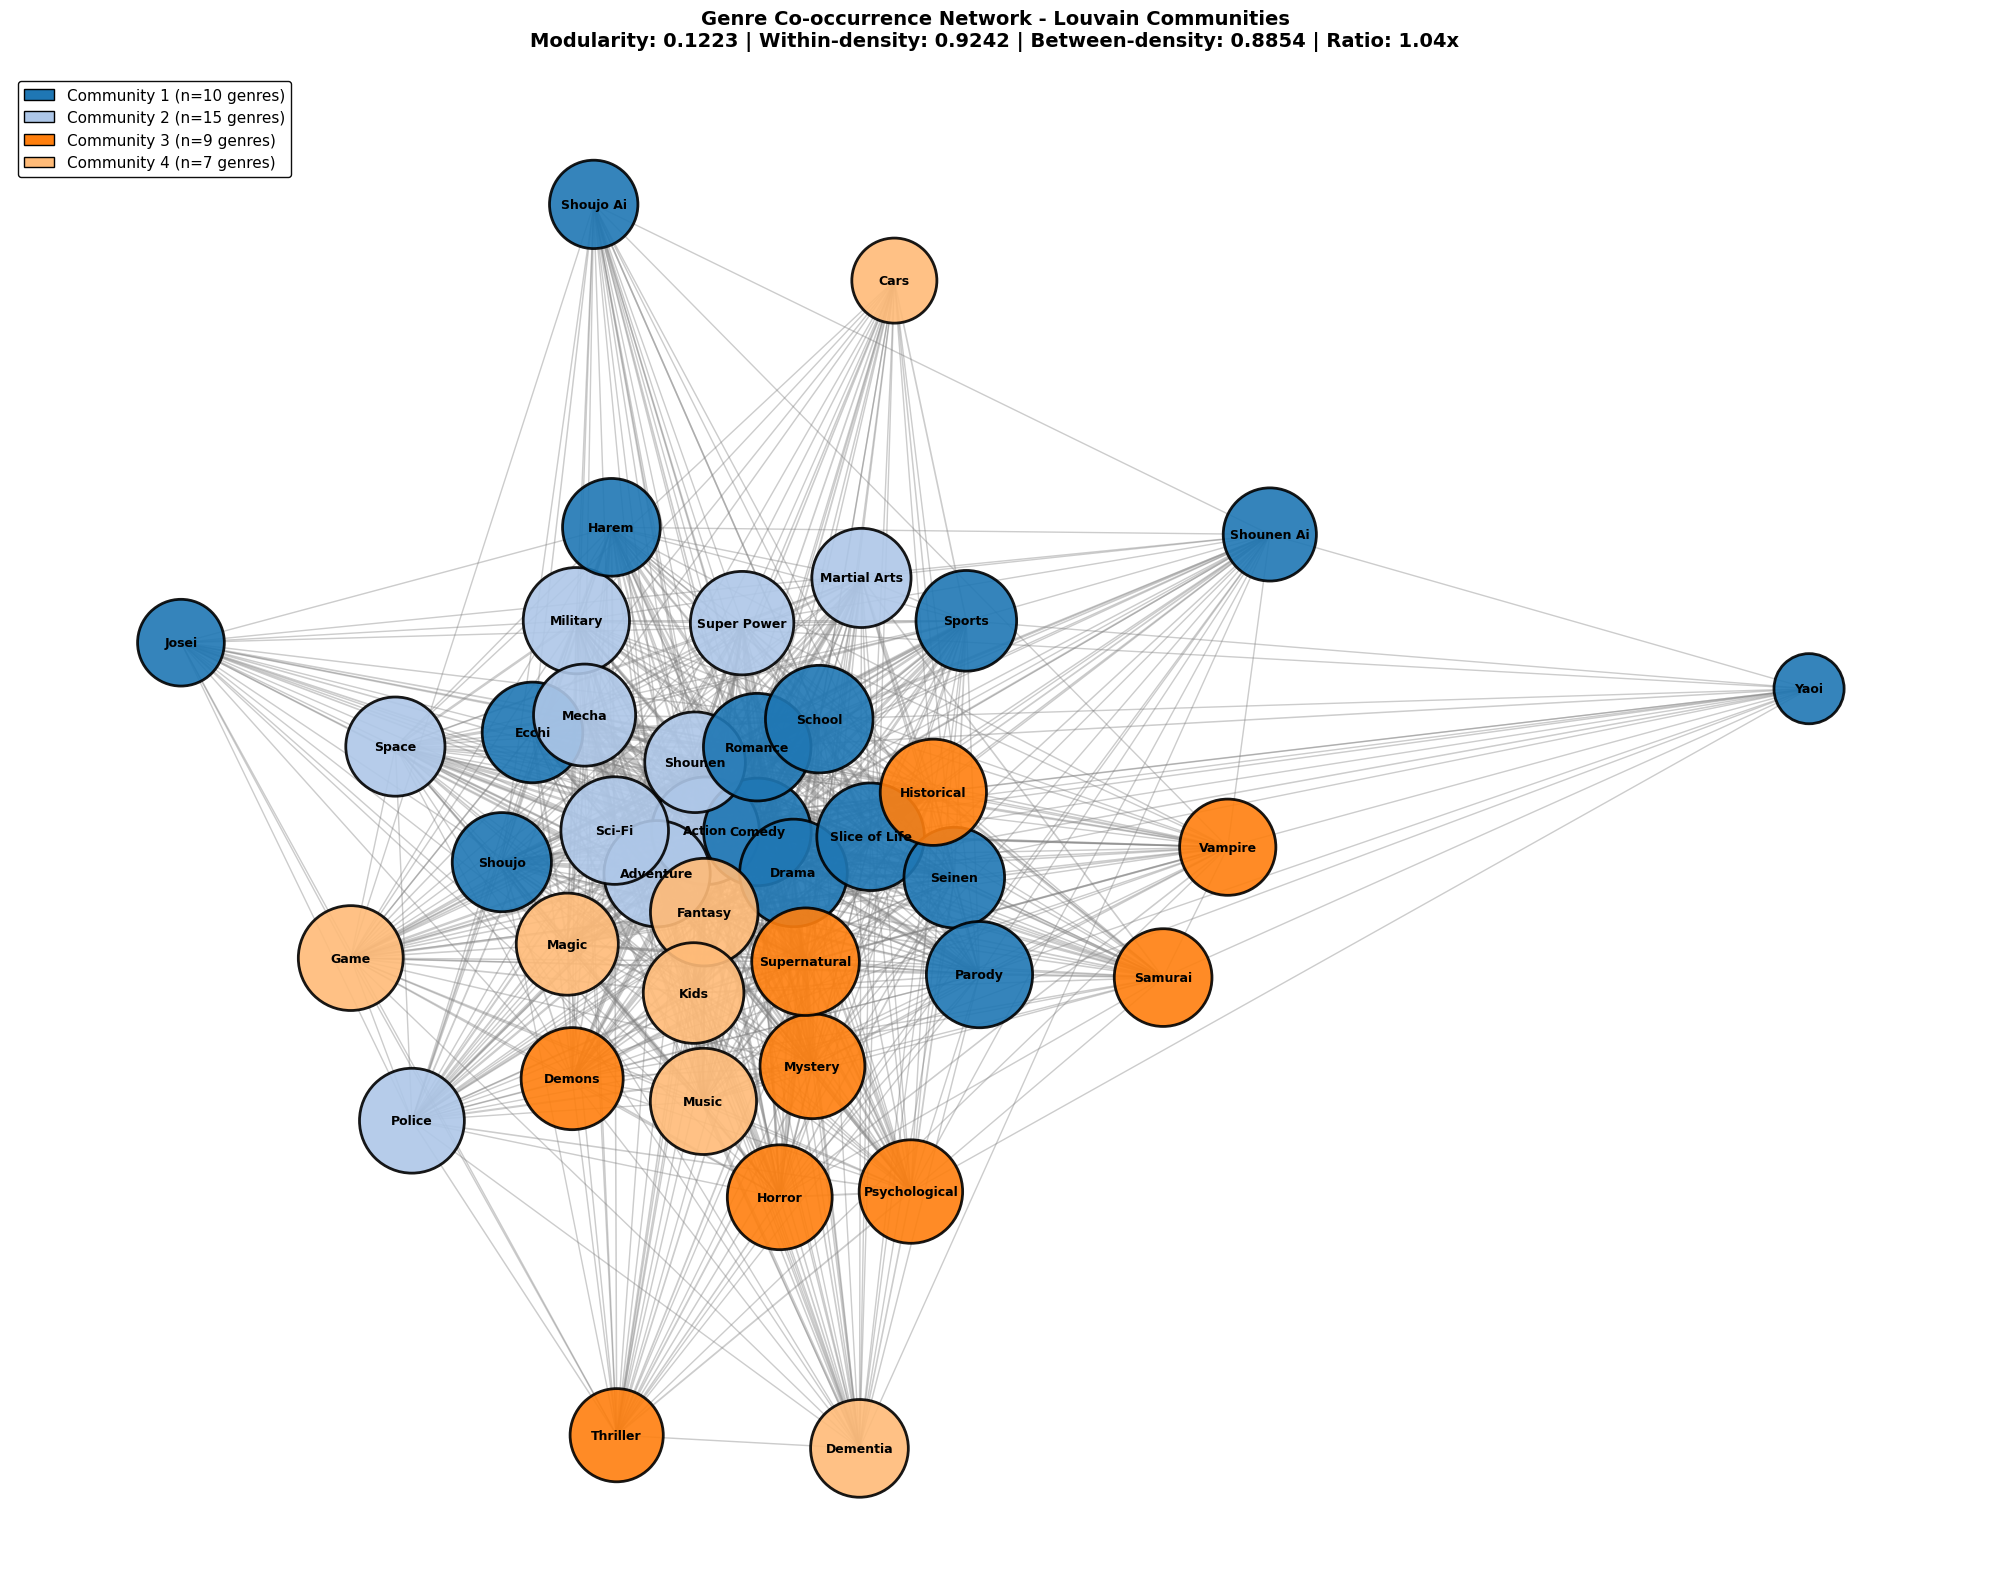


✓ NETWORK 1 ANALYSIS COMPLETE!

Results saved for Phase 3 Synthesis


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================================
# PHASE 3: NETWORK 1 - GENRE CO-OCCURRENCE NETWORK ANALYSIS
# ============================================================================

"""
PHASE 3 NETWORK 1 OVERVIEW:
---------------------------
Goal: Analyze the genre co-occurrence network to answer:
"Are genres naturally organized into communities?"

This script:
1. Runs Louvain algorithm on the pre-built genre network
2. Extracts and validates communities
3. Calculates modularity and density measures
4. Visualizes the network with communities
5. Provides interpretation of findings
"""

def analyze_louvain_and_calculate_measures(graph):
    """
    Run Louvain algorithm and calculate network measures
    """
    try:
        from community import community_louvain
    except ImportError:
        print("\n" + "!"*70)
        print("ERROR: python-louvain package not installed")
        print("!"*70)
        print("\nTo install, run:")
        print("  pip install python-louvain")
        print("!"*70)
        return None

    print("\n" + "="*70)
    print("PHASE 3: NETWORK 1 - GENRE CO-OCCURRENCE NETWORK ANALYSIS")
    print("="*70)

    # =========================================================================
    # STEP 1: RUN LOUVAIN ALGORITHM
    # =========================================================================

    print("\n[STEP 1] Running Louvain Algorithm...")
    print("-" * 70)

    import time
    start_time = time.time()

    # Run Louvain with fixed seed for reproducibility
    partition = community_louvain.best_partition(
        graph,
        weight='weight',
        randomize=None,
        random_state=42
    )

    elapsed_time = time.time() - start_time

    # Convert partition to communities list
    communities_dict = defaultdict(list)
    for node, community_id in partition.items():
        communities_dict[community_id].append(node)

    communities_list = list(communities_dict.values())

    print(f"✓ Algorithm completed in {elapsed_time:.2f} seconds")
    print(f"✓ Found {len(communities_list)} communities")

    # =========================================================================
    # STEP 2: CALCULATE MODULARITY SCORE
    # =========================================================================

    print("\n[STEP 2] Calculating Modularity")
    print("-" * 70)

    # Calculate modularity using the community_louvain module
    modularity_score = community_louvain.modularity(
        partition,
        graph,
        weight='weight'
    )

    print(f"\n✓ Modularity Score: {modularity_score:.4f}")
    print(f"\nWhat this means:")
    print(f"  • Modularity ranges from 0 to 1")
    print(f"  • Measures how well-separated communities are")
    print(f"  • >0.4 typically indicates strong community structure")

    if modularity_score > 0.4:
        interpretation = "STRONG ✅"
        detail = "Genres are well-organized into distinct communities."
    elif modularity_score > 0.3:
        interpretation = "MODERATE ✓"
        detail = "Communities exist but with some overlap."
    else:
        interpretation = "WEAK ⚠️"
        detail = "Communities are not well-separated."

    print(f"\nVerdict: {interpretation}")
    print(f"Detail: {detail}")

    # =========================================================================
    # STEP 3: DISPLAY BASIC STATISTICS
    # =========================================================================

    print("\n[STEP 3] Basic Network Statistics")
    print("-" * 70)
    print(f"Total genres (nodes):     {graph.number_of_nodes()}")
    print(f"Total connections (edges): {graph.number_of_edges()}")
    print(f"Number of communities:    {len(communities_list)}")

    # =========================================================================
    # STEP 4: CALCULATE WITHIN-COMMUNITY DENSITY
    # =========================================================================

    print("\n[STEP 4] Within-Community Density")
    print("-" * 70)
    print(f"\nHow tightly connected is each community?")
    print(f"(Higher = genres in same community co-occur frequently)")
    print(f"{'-'*70}")

    within_densities = []
    community_info = []

    # Sort communities by size for clearer presentation
    sorted_communities = sorted(
        enumerate(communities_list),
        key=lambda x: len(x[1]),
        reverse=True
    )

    for idx, community_set in sorted_communities:
        community_size = len(community_set)

        # Calculate internal edges (edges within the community)
        internal_edges = 0
        for node1 in community_set:
            for node2 in community_set:
                if node1 < node2 and graph.has_edge(node1, node2):
                    internal_edges += 1

        # Calculate external edges (edges going outside the community)
        external_edges = 0
        for node in community_set:
            for neighbor in graph.neighbors(node):
                if neighbor not in community_set:
                    external_edges += 1

        # Calculate density
        # Density = actual edges / possible edges
        max_possible_edges = community_size * (community_size - 1) / 2
        density = internal_edges / max_possible_edges if community_size > 1 else 0

        within_densities.append(density)

        # SEMANTIC MEANING: What does this density tell us?
        if density > 0.5:
            density_interpretation = "High - genres co-occur frequently ✅"
        elif density > 0.3:
            density_interpretation = "Moderate - some co-occurrence"
        else:
            density_interpretation = "Low - genres rarely co-occur"

        print(f"\n🎬 Community {idx + 1}: ({community_size} genres)")
        print(f"   Genres: {', '.join(sorted(community_set))}")
        print(f"   Internal edges: {internal_edges}")
        print(f"   External edges: {external_edges}")
        print(f"   Density: {density:.4f} → {density_interpretation}")

        community_info.append({
            'id': idx,
            'size': community_size,
            'genres': sorted(community_set),
            'internal_edges': internal_edges,
            'external_edges': external_edges,
            'density': density
        })

    # Calculate average within-community density
    avg_within = np.mean(within_densities)
    print(f"\n{'='*70}")
    print(f"Average Within-Community Density: {avg_within:.4f}")
    print(f"{'='*70}")

    # =========================================================================
    # STEP 5: CALCULATE BETWEEN-COMMUNITY DENSITY
    # =========================================================================

    print("\n[STEP 5] Between-Community Density")
    print("-" * 70)
    print(f"\nHow much do different communities mix?")
    print(f"(Lower = communities are well-separated)")
    print(f"{'-'*70}")

    between_densities = {}

    # Sort communities for pairing
    sorted_communities_list = [c[1] for c in sorted_communities]

    for i in range(len(sorted_communities_list)):
        for j in range(i+1, len(sorted_communities_list)):
            community_i = sorted_communities_list[i]
            community_j = sorted_communities_list[j]

            # Count edges between the two communities
            edges_between = 0
            for node1 in community_i:
                for node2 in community_j:
                    if graph.has_edge(node1, node2):
                        edges_between += 1

            # Possible edges between communities
            max_possible_between = len(community_i) * len(community_j)

            # Calculate density
            density_between = edges_between / max_possible_between if max_possible_between > 0 else 0

            between_densities[(i+1, j+1)] = density_between

            # SEMANTIC MEANING: What does this tell us about community separation?
            if density_between < 0.05:
                separation = "Well-separated ✅"
            elif density_between < 0.1:
                separation = "Mostly separated"
            else:
                separation = "Significant mixing"

            print(f"\nCommunity {i+1} ↔ Community {j+1}")
            print(f"   Edges between: {edges_between}")
            print(f"   Density: {density_between:.4f} → {separation}")

    # Calculate average between-community density
    avg_between = np.mean(list(between_densities.values())) if between_densities else 0
    print(f"\n{'='*70}")
    print(f"Average Between-Community Density: {avg_between:.4f}")
    print(f"{'='*70}")

    # =========================================================================
    # STEP 6: DENSITY RATIO ANALYSIS
    # =========================================================================

    print("\n[STEP 6] Within vs Between Density Analysis")
    print("-" * 70)

    ratio = avg_within / avg_between if avg_between > 0 else float('inf')

    print(f"\nWithin-to-Between Density Ratio: {ratio:.2f}x")
    print(f"\nWhat this means:")
    print(f"  • Higher ratio = better community separation")
    print(f"  • Shows how much tighter within-community connections are")

    if ratio > 5:
        print(f"  → Excellent separation ✅")
    elif ratio > 2:
        print(f"  → Good separation ✓")
    else:
        print(f"  → Weak separation ⚠️")

    # =========================================================================
    # STEP 7: CONNECTIVITY AND COHESION
    # =========================================================================

    print("\n[STEP 7] Network Cohesion Measures")
    print("-" * 70)

    # Average degree
    degrees = [graph.degree(n) for n in graph.nodes()]
    avg_degree = np.mean(degrees)

    print(f"\nAverage genre degree: {avg_degree:.2f}")
    print(f"  → On average, each genre connects to {avg_degree:.1f} other genres")

    # Network clustering
    avg_clustering = nx.average_clustering(graph)
    print(f"\nAverage clustering coefficient: {avg_clustering:.4f}")
    print(f"  → Measures how likely neighbors are also neighbors")

    if avg_clustering > 0.3:
        print(f"  → Strong clustering: tight genre patterns ✅")
    else:
        print(f"  → Moderate clustering")

    # Network components
    num_components = nx.number_connected_components(graph)
    print(f"\nNetwork components: {num_components}")
    if num_components == 1:
        print(f"  → Network is fully connected ✅")
    else:
        print(f"  → Network has {num_components} disconnected parts")

    # =========================================================================
    # STEP 8: FINAL SUMMARY AND INTERPRETATION
    # =========================================================================

    print("\n[STEP 8] Final Summary")
    print("="*70)

    # Aggregate evidence
    evidence_score = 0

    # Evidence 1: Modularity
    if modularity_score > 0.4:
        evidence_score += 3
        mod_evidence = "✅ Strong modularity (>0.4)"
    elif modularity_score > 0.3:
        evidence_score += 2
        mod_evidence = "✓ Moderate modularity (0.3-0.4)"
    else:
        evidence_score += 1
        mod_evidence = "⚠️ Weak modularity (<0.3)"

    # Evidence 2: Density ratio
    if ratio > 5:
        evidence_score += 3
        density_evidence = "✅ Excellent within/between separation (ratio >5)"
    elif ratio > 2:
        evidence_score += 2
        density_evidence = "✓ Good within/between separation (ratio >2)"
    else:
        evidence_score += 1
        density_evidence = "⚠️ Weak within/between separation (ratio <2)"

    # Evidence 3: Clustering
    if avg_clustering > 0.3:
        evidence_score += 2
        cluster_evidence = "✓ Strong clustering patterns"
    else:
        evidence_score += 1
        cluster_evidence = "⚠️ Moderate clustering"

    print(f"\nEvidence Summary:")
    print(f"  1. {mod_evidence}")
    print(f"  2. {density_evidence}")
    print(f"  3. {cluster_evidence}")

    print(f"\nTotal Evidence Score: {evidence_score}/8")
    print(f"\n{'='*70}")

    # Final answer
    if evidence_score >= 7:
        answer = "YES - STRONG EVIDENCE ✅✅✅"
        conclusion = "Genres are strongly organized into natural communities.\n" \
                    "The communities are well-separated and internally cohesive."
    elif evidence_score >= 5:
        answer = "YES - MODERATE EVIDENCE ✓✓"
        conclusion = "Genres show community organization with some overlap.\n" \
                    "Communities are distinguishable but not completely separate."
    else:
        answer = "WEAK EVIDENCE ⚠️"
        conclusion = "Genres do not show clear community organization.\n" \
                    "Communities are not well-separated."

    print(f"RESEARCH QUESTION: Are genres naturally organized into communities?")
    print(f"ANSWER: {answer}")
    print(f"CONCLUSION: {conclusion}")
    print(f"{'='*70}\n")

    # =========================================================================
    # RETURN ALL RESULTS
    # =========================================================================

    return {
        'partition': partition,
        'communities': communities_list,
        'modularity': modularity_score,
        'within_densities': within_densities,
        'between_densities': between_densities,
        'avg_within': avg_within,
        'avg_between': avg_between,
        'ratio': ratio,
        'community_info': community_info,
        'avg_degree': avg_degree,
        'avg_clustering': avg_clustering,
        'time': elapsed_time
    }


def visualize_louvain_communities(graph, partition, results):
    """
    Visualize the Louvain communities with enhanced information and visible edges
    """
    print("\n[STEP 9] Creating Visualization...")
    print("-" * 70)

    # Convert partition to communities
    communities_dict = defaultdict(list)
    for node, community_id in partition.items():
        communities_dict[community_id].append(node)

    communities_list = list(communities_dict.values())

    # Create colors for communities
    colors = plt.cm.tab20(range(len(communities_list)))

    # Map nodes to community colors
    node_to_community = {node: idx for idx, (_, nodes) in enumerate(sorted(
        communities_dict.items(),
        key=lambda x: len(x[1]),
        reverse=True
    )) for node in nodes}

    node_colors = [colors[node_to_community[node]] for node in graph.nodes()]

    # Create plot with larger figure size for better visibility
    fig, ax = plt.subplots(figsize=(20, 16))

    # Layout
    pos = nx.spring_layout(graph, k=2.5, iterations=100, seed=42, weight='weight')

    # ─────────────────────────────────────────────────────────────────
    # DRAW EDGES (THICKER AND MORE VISIBLE)
    # ─────────────────────────────────────────────────────────────────

    edges = graph.edges()
    weights = [graph[u][v]['weight'] for u, v in edges]

    if weights:
        max_weight = max(weights)
        min_weight = min(weights)

        # Normalize weights to thicker line widths (1 to 8)
        # This makes edges much more visible
        normalized_weights = [
            1 + (w - min_weight) / (max_weight - min_weight) * 7
            for w in weights
        ]
    else:
        normalized_weights = [1] * len(edges)

    # Draw edges with thicker lines and higher alpha for visibility
    nx.draw_networkx_edges(
        graph, pos,
        width=normalized_weights,
        alpha=0.4,  # Increased from 0.2 for better visibility
        ax=ax,
        edge_color='gray'
    )

    # ─────────────────────────────────────────────────────────────────
    # DRAW NODES
    # ─────────────────────────────────────────────────────────────────

    # Size nodes based on their degree (connectivity)
    node_sizes = [graph.degree(node) * 150 for node in graph.nodes()]

    nx.draw_networkx_nodes(
        graph, pos,
        node_color=node_colors,
        node_size=node_sizes,
        ax=ax,
        alpha=0.9,
        edgecolors='black',
        linewidths=2
    )

    # ─────────────────────────────────────────────────────────────────
    # DRAW LABELS
    # ─────────────────────────────────────────────────────────────────

    nx.draw_networkx_labels(
        graph, pos,
        font_size=9,
        font_weight='bold',
        ax=ax,
        font_color='black'
    )

    # ─────────────────────────────────────────────────────────────────
    # TITLE
    # ─────────────────────────────────────────────────────────────────

    title = f'Genre Co-occurrence Network - Louvain Communities\n' \
            f'Modularity: {results["modularity"]:.4f} | ' \
            f'Within-density: {results["avg_within"]:.4f} | ' \
            f'Between-density: {results["avg_between"]:.4f} | ' \
            f'Ratio: {results["ratio"]:.2f}x'

    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')

    # ─────────────────────────────────────────────────────────────────
    # LEGEND
    # ─────────────────────────────────────────────────────────────────

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[i], edgecolor='black', label=f'Community {i+1} (n={len(communities_list[i])} genres)')
        for i in range(len(communities_list))
    ]
    ax.legend(
        handles=legend_elements,
        loc='upper left',
        fontsize=11,
        framealpha=0.95,
        edgecolor='black'
    )

    plt.tight_layout()
    plt.savefig('network1_genre_communities.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Visualization saved as 'network1_genre_communities.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

# Run the analysis
network1_results = analyze_louvain_and_calculate_measures(Genres)

# Visualize
visualize_louvain_communities(Genres, network1_results['partition'], network1_results)

print("\n" + "="*70)
print("✓ NETWORK 1 ANALYSIS COMPLETE!")
print("="*70)
print("\nResults saved for Phase 3 Synthesis")

# Network 2 Analysis - Bipartite Anime - Genre Communities


STARTING NETWORK 2 ANALYSIS

PHASE 3: NETWORK 2 - ANIME-COMMUNITY DISTRIBUTION ANALYSIS

[STEP 1] Loading Anime-Community Assignments from Phase 2 (Revised)
----------------------------------------------------------------------

✓ Loaded assignments DataFrame
  Total anime: 16151
  Columns: ['anime_id', 'anime_name', 'genres', 'num_genres', 'assigned_communities', 'confidence', 'communities_spanned', 'is_bridge', 'community_distribution', 'all_community_names']

Sample assignments:
                        anime_name assigned_communities  confidence  is_bridge
0                     Cowboy Bebop                  [1]    0.666667      False
1  Cowboy Bebop: Tengoku no Tobira                  [1]    0.600000      False
2                           Trigun                  [1]    0.666667      False
3               Witch Hunter Robin               [1, 3]    0.500000       True
4                   Bouken Ou Beet                  [1]    0.750000      False
5                     Eyeshield 21    

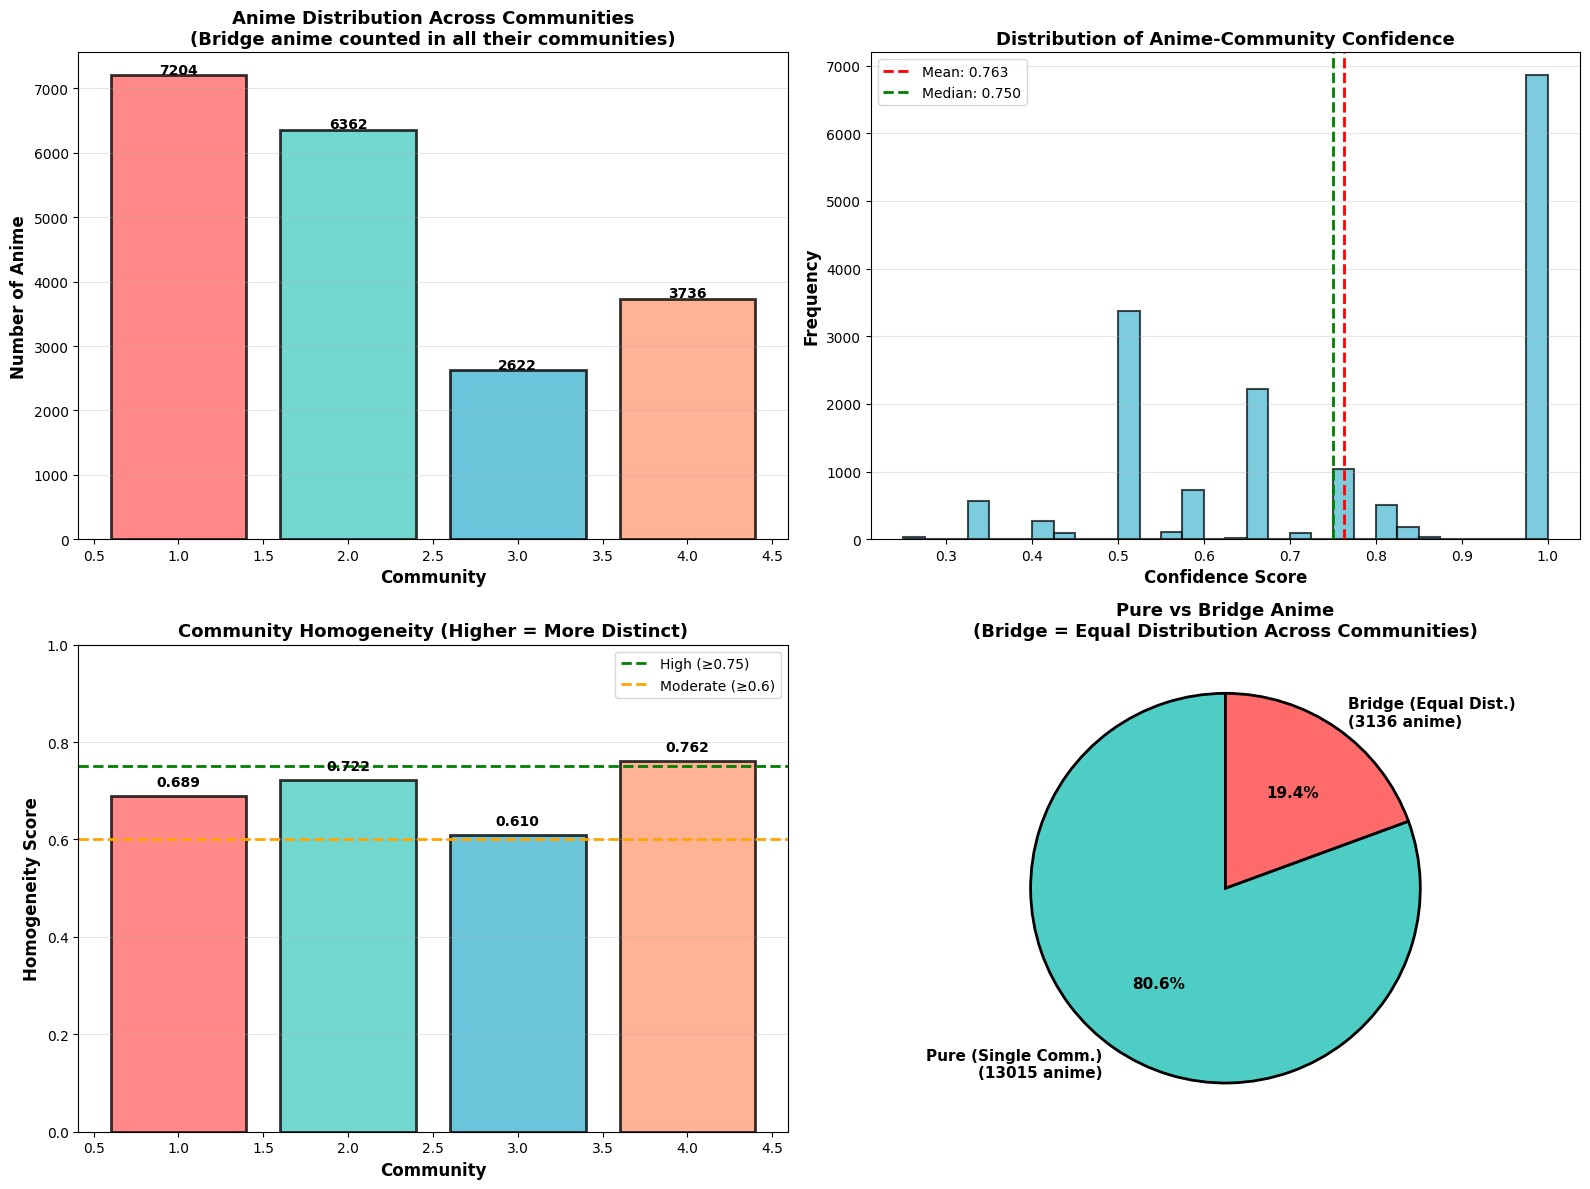


✓ NETWORK 2 ANALYSIS COMPLETE!

Next: Network 3 - User-Community Analysis


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns

# ============================================================================
# PHASE 3: NETWORK 2 - ANIME-COMMUNITY DISTRIBUTION ANALYSIS (REVISED)
# ============================================================================

"""
PHASE 3 NETWORK 2 OVERVIEW (REVISED):
-------------------------------------
Goal: Analyze how anime distribute across genre communities to answer:
"Do communities get distinct anime, or do they heavily overlap?"

KEY DIFFERENCE FROM ORIGINAL:
- Bridge anime = equal distribution across multiple communities (true bridges)
- Non-bridge anime = assigned to single community with most genres

This script:
1. Loads the anime-community assignments from Phase 2 (revised)
2. Analyzes anime distribution across communities
3. Identifies and analyzes TRUE bridge anime (equal distribution)
4. Calculates community homogeneity
5. Visualizes anime clustering by community
"""

def load_and_validate_assignments(assignments_df):
    """
    [STEP 1] Load and validate the anime-community assignments from Phase 2 (revised)

    This loads the DataFrame we created in Phase 2 and validates it's intact.
    Key difference: now handles multiple assigned communities and true bridges.

    Args:
    - assignments_df: DataFrame from Phase 2 (revised) with anime assignments

    Returns:
    - assignments_df: Validated DataFrame with all necessary columns
    """
    print("\n" + "="*70)
    print("PHASE 3: NETWORK 2 - ANIME-COMMUNITY DISTRIBUTION ANALYSIS")
    print("="*70)

    print("\n[STEP 1] Loading Anime-Community Assignments from Phase 2 (Revised)")
    print("-" * 70)

    print(f"\n✓ Loaded assignments DataFrame")
    print(f"  Total anime: {len(assignments_df)}")
    print(f"  Columns: {list(assignments_df.columns)}")

    # Verify required columns exist
    required_cols = ['anime_id', 'anime_name', 'assigned_communities',
                     'confidence', 'is_bridge', 'communities_spanned']

    missing_cols = [col for col in required_cols if col not in assignments_df.columns]
    if missing_cols:
        print(f"\n⚠️  Warning: Missing columns: {missing_cols}")
        print(f"   Some analyses may be limited")

    # Display sample data
    print(f"\nSample assignments:")
    print(assignments_df[['anime_name', 'assigned_communities', 'confidence', 'is_bridge']].head(10))

    return assignments_df


def analyze_anime_distribution(assignments_df):
    """
    [STEP 2] Analyze how anime distribute across communities

    This measures:
    - How many anime in each community (counting bridges in all their communities)
    - Are communities well-populated or sparse?
    - Do anime evenly distribute or cluster in some communities?

    SEMANTIC MEANING:
    If anime distribute evenly across communities, it suggests genres
    don't create distinct anime groups. If they cluster, communities
    have distinct anime profiles.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - distribution_stats: Dictionary with distribution statistics
    """
    print("\n[STEP 2] Analyzing Anime Distribution Across Communities")
    print("-" * 70)

    # Count anime per community
    # Important: Bridge anime count in multiple communities
    community_anime_counts = defaultdict(set)

    for idx, row in assignments_df.iterrows():
        for community in row['assigned_communities']:
            community_anime_counts[community].add(row['anime_id'])

    # Convert to counts
    community_counts = {comm: len(anime_set) for comm, anime_set in community_anime_counts.items()}
    community_counts = pd.Series(community_counts).sort_index()

    print(f"\nAnime Count per Community:")
    print(f"(Note: Bridge anime are counted in all their communities)")
    for community_id, count in community_counts.items():
        percentage = (count / len(assignments_df)) * 100
        print(f"  Community {community_id}: {count:5d} anime ({percentage:5.1f}%)")

    # Calculate distribution statistics
    mean_anime = community_counts.mean()
    std_anime = community_counts.std()
    min_anime = community_counts.min()
    max_anime = community_counts.max()

    print(f"\nDistribution Statistics:")
    print(f"  Mean anime per community: {mean_anime:.1f}")
    print(f"  Std deviation: {std_anime:.1f}")
    print(f"  Min: {min_anime}")
    print(f"  Max: {max_anime}")

    # Coefficient of variation (how uneven is the distribution?)
    if mean_anime > 0:
        cv = (std_anime / mean_anime) * 100
        print(f"  Coefficient of variation: {cv:.1f}%")

        if cv < 20:
            print(f"  → Very even distribution (communities are similar size)")
        elif cv < 50:
            print(f"  → Moderate variation (some communities larger than others)")
        else:
            print(f"  → High variation (communities are quite different sizes)")

    stats = {
        'community_counts': community_counts,
        'mean': mean_anime,
        'std': std_anime,
        'min': min_anime,
        'max': max_anime,
        'cv': cv
    }

    return stats


def analyze_confidence_scores(assignments_df):
    """
    [STEP 3] Analyze anime-community confidence scores

    Confidence = (# of anime's genres in assigned community) / (total genres)

    For bridge anime: confidence is the % of genres in each of their communities
    (should be equal for true bridges)

    This measures:
    - How well do anime match their assigned communities?
    - Are assignments clear-cut or ambiguous?
    - Are there many "border" anime (low confidence)?

    SEMANTIC MEANING:
    High confidence means anime clearly belong to a community (most of their
    genres are in that community). Low confidence means anime are borderline.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - confidence_stats: Dictionary with confidence statistics
    """
    print("\n[STEP 3] Analyzing Anime-Community Confidence Scores")
    print("-" * 70)

    print(f"\nConfidence Score Statistics:")
    print(f"  (Higher confidence = anime clearly match their community/communities)")
    print(f"  {'-'*70}")

    print(f"\n  Mean: {assignments_df['confidence'].mean():.4f}")
    print(f"  Median: {assignments_df['confidence'].median():.4f}")
    print(f"  Std Dev: {assignments_df['confidence'].std():.4f}")
    print(f"  Min: {assignments_df['confidence'].min():.4f}")
    print(f"  Max: {assignments_df['confidence'].max():.4f}")

    # Distribution of confidence scores
    print(f"\nConfidence Score Distribution:")
    confidence_bins = pd.cut(assignments_df['confidence'],
                             bins=[0, 0.25, 0.5, 0.75, 1.0],
                             labels=['0-0.25', '0.25-0.5', '0.5-0.75', '0.75-1.0'])
    bin_counts = confidence_bins.value_counts().sort_index()

    for bin_label, count in bin_counts.items():
        percentage = (count / len(assignments_df)) * 100
        bar = '█' * int(percentage / 2)
        print(f"  {bin_label}: {count:5d} anime ({percentage:5.1f}%) {bar}")

    # Interpretation
    high_conf = len(assignments_df[assignments_df['confidence'] >= 0.75])
    high_conf_pct = (high_conf / len(assignments_df)) * 100

    low_conf = len(assignments_df[assignments_df['confidence'] < 0.5])
    low_conf_pct = (low_conf / len(assignments_df)) * 100

    print(f"\nInterpretation:")
    print(f"  High confidence (≥0.75): {high_conf:5d} anime ({high_conf_pct:5.1f}%)")
    print(f"  Low confidence (<0.5):   {low_conf:5d} anime ({low_conf_pct:5.1f}%)")

    if high_conf_pct > 70:
        print(f"  → Most anime clearly match their communities ✅")
    elif high_conf_pct > 50:
        print(f"  → Many anime match their communities")
    else:
        print(f"  → Communities are ambiguous, many borderline anime ⚠️")

    stats = {
        'mean_confidence': assignments_df['confidence'].mean(),
        'median_confidence': assignments_df['confidence'].median(),
        'high_conf_count': high_conf,
        'high_conf_pct': high_conf_pct,
        'low_conf_count': low_conf,
        'low_conf_pct': low_conf_pct
    }

    return stats


def analyze_bridge_anime_revised(assignments_df):
    """
    [STEP 4] Analyze TRUE bridge anime (equal distribution across communities)

    In the revised Phase 2:
    - Bridge anime have EQUAL genre distribution across multiple communities
    - They serve as gateways between communities
    - They represent the strongest connections between communities

    This measures:
    - How many true bridge anime exist?
    - Which communities do they connect?
    - What's their confidence level?

    SEMANTIC MEANING:
    True bridge anime show natural genre connections between communities.
    They indicate which communities are most similar or complementary.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - bridge_stats: Dictionary with bridge anime statistics
    """
    print("\n[STEP 4] Analyzing TRUE Bridge Anime (Equal Distribution)")
    print("-" * 70)

    bridge_anime = assignments_df[assignments_df['is_bridge']]
    pure_anime = assignments_df[~assignments_df['is_bridge']]

    bridge_pct = (len(bridge_anime) / len(assignments_df)) * 100
    pure_pct = (len(pure_anime) / len(assignments_df)) * 100

    print(f"\nBridge vs Pure Anime:")
    print(f"  Pure anime (single community): {len(pure_anime):5d} ({pure_pct:5.1f}%)")
    print(f"  Bridge anime (equal distribution): {len(bridge_anime):5d} ({bridge_pct:5.1f}%)")

    if bridge_pct > 50:
        print(f"  → Most anime are true bridges (communities heavily connected) ⚠️")
    elif bridge_pct > 30:
        print(f"  → Significant bridging between communities")
    else:
        print(f"  → Few anime truly bridge communities (good separation) ✅")

    # Distribution of how many communities bridge anime span
    print(f"\nBridge Anime Distribution (by communities spanned):")
    if len(bridge_anime) > 0:
        span_dist = bridge_anime['communities_spanned'].value_counts().sort_index()
        for num_communities, count in span_dist.items():
            percentage = (count / len(bridge_anime)) * 100
            print(f"  Spanning {num_communities} communities: {count:5d} anime ({percentage:5.1f}%)")

        # Average communities spanned
        avg_span = bridge_anime['communities_spanned'].mean()
        print(f"\n  Average communities spanned: {avg_span:.2f}")

    # Top bridge anime (those connecting the most communities)
    if len(bridge_anime) > 0:
        print(f"\nTop Bridge Anime (spanning most communities):")
        top_bridges = bridge_anime.nlargest(5, 'communities_spanned')[
            ['anime_name', 'assigned_communities', 'communities_spanned', 'confidence']
        ]
        for idx, row in top_bridges.iterrows():
            print(f"  • {row['anime_name']}")
            print(f"    Communities: {row['assigned_communities']}")
            print(f"    Spans {row['communities_spanned']} communities (confidence: {row['confidence']:.2f})")

    stats = {
        'total_bridge': len(bridge_anime),
        'bridge_pct': bridge_pct,
        'total_pure': len(pure_anime),
        'pure_pct': pure_pct
    }

    if len(bridge_anime) > 0:
        stats['avg_span'] = bridge_anime['communities_spanned'].mean()

    return stats


def analyze_community_homogeneity_revised(assignments_df):
    """
    [STEP 5] Analyze community homogeneity

    Homogeneity measures how "pure" a community is.
    - High homogeneity: community has anime with mostly that community's genres
    - Low homogeneity: community has diverse anime from multiple genre sources

    For BRIDGE ANIME: they contribute to lowering homogeneity because their
    genres are equally distributed across communities (by definition).

    SEMANTIC MEANING:
    High homogeneity means a community has a distinct anime profile - anime
    in that community tend to have genres primarily from that community.
    Low homogeneity means community members are diverse genre-wise, possibly
    due to bridging anime.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - homogeneity_stats: Dictionary with homogeneity per community
    """
    print("\n[STEP 5] Analyzing Community Homogeneity")
    print("-" * 70)

    print(f"\nCommunity Homogeneity (based on confidence scores):")
    print(f"(Higher = more distinct anime profile)")
    print(f"(Note: bridge anime lower homogeneity due to equal distribution)")
    print(f"{'-'*70}")

    homogeneity_stats = {}

    # Get unique communities
    all_communities = set()
    for communities_list in assignments_df['assigned_communities']:
        all_communities.update(communities_list)

    for community_id in sorted(all_communities):
        # Get all anime assigned to this community
        anime_in_community = assignments_df[
            assignments_df['assigned_communities'].apply(lambda x: community_id in x)
        ]

        if len(anime_in_community) > 0:
            # Homogeneity = average confidence of anime in this community
            homogeneity = anime_in_community['confidence'].mean()

            # Also calculate bridge vs pure anime
            bridge_in_community = len(anime_in_community[anime_in_community['is_bridge']])
            pure_in_community = len(anime_in_community[~anime_in_community['is_bridge']])

            # How many high-confidence anime
            high_conf_count = len(anime_in_community[anime_in_community['confidence'] >= 0.75])
            high_conf_pct = (high_conf_count / len(anime_in_community)) * 100

            homogeneity_stats[community_id] = {
                'homogeneity': homogeneity,
                'anime_count': len(anime_in_community),
                'bridge_anime': bridge_in_community,
                'pure_anime': pure_in_community,
                'high_conf_count': high_conf_count,
                'high_conf_pct': high_conf_pct,
                'std_confidence': anime_in_community['confidence'].std()
            }

            # Interpret homogeneity
            if homogeneity >= 0.8:
                interpretation = "Very high - distinct anime profile ✅"
            elif homogeneity >= 0.6:
                interpretation = "Moderate - some variation"
            else:
                interpretation = "Low - diverse anime ⚠️"

            print(f"\nCommunity {community_id}:")
            print(f"  Homogeneity: {homogeneity:.4f} → {interpretation}")
            print(f"  Anime in community: {len(anime_in_community)}")
            print(f"    - Pure anime: {pure_in_community}")
            print(f"    - Bridge anime: {bridge_in_community}")
            print(f"  High-confidence anime: {high_conf_count} ({high_conf_pct:.1f}%)")

    # Overall homogeneity
    overall_homogeneity = np.mean([s['homogeneity'] for s in homogeneity_stats.values()])
    print(f"\n{'='*70}")
    print(f"Overall Community Homogeneity: {overall_homogeneity:.4f}")
    print(f"{'='*70}")

    if overall_homogeneity >= 0.75:
        print(f"Interpretation: Communities have distinct anime profiles ✅")
    elif overall_homogeneity >= 0.60:
        print(f"Interpretation: Communities have some distinct profiles")
    else:
        print(f"Interpretation: Communities are not well-separated by anime ⚠️")

    return homogeneity_stats


def analyze_bridge_connections(assignments_df):
    """
    [STEP 6] Analyze which communities are connected by bridge anime

    For each pair of communities, count how many bridge anime connect them.
    This shows the strength of connections between communities.

    SEMANTIC MEANING:
    Many bridge anime between two communities means those communities have
    genres that naturally occur together. Strong connections indicate
    communities are not truly isolated.

    Args:
    - assignments_df: DataFrame with anime assignments

    Returns:
    - bridge_connections: DataFrame showing pairwise connections
    """
    print("\n[STEP 6] Analyzing Bridge Connections Between Communities")
    print("-" * 70)

    # Get all bridge anime
    bridge_anime = assignments_df[assignments_df['is_bridge']]

    # Get all communities
    all_communities = set()
    for communities_list in assignments_df['assigned_communities']:
        all_communities.update(communities_list)

    # Initialize connection matrix
    connection_matrix = pd.DataFrame(
        0,
        index=sorted(all_communities),
        columns=sorted(all_communities)
    )

    print(f"\nBridge Anime Connections Between Communities:")
    print(f"{'-'*70}")

    # For each bridge anime, add connections between its communities
    for idx, row in bridge_anime.iterrows():
        communities_in_anime = row['assigned_communities']

        # Add connection for each pair
        for i in range(len(communities_in_anime)):
            for j in range(i + 1, len(communities_in_anime)):
                c1 = communities_in_anime[i]
                c2 = communities_in_anime[j]
                connection_matrix.loc[c1, c2] += 1
                connection_matrix.loc[c2, c1] += 1

    # Display connection matrix
    print(f"\nConnection Matrix (number of bridge anime connecting communities):")
    print(connection_matrix.astype(int))

    # Find strongest connections
    print(f"\nStrongest Community Connections (via bridge anime):")
    connections = []
    for i in sorted(all_communities):
        for j in sorted(all_communities):
            if i < j and connection_matrix.loc[i, j] > 0:
                connections.append((i, j, connection_matrix.loc[i, j]))

    # Sort by strength
    connections.sort(key=lambda x: x[2], reverse=True)

    if connections:
        for c1, c2, strength in connections[:5]:
            print(f"  Community {c1} ↔ Community {c2}: {strength} bridge anime")
    else:
        print(f"  No bridge connections found (all anime assigned to single communities)")

    return connection_matrix


def generate_network2_summary(assignments_df, dist_stats, conf_stats,
                               bridge_stats, homogeneity_stats):
    """
    [STEP 7] Generate comprehensive summary of Network 2 findings

    Synthesizes all measures to answer:
    "Do communities get distinct anime, or do they heavily overlap?"

    Args:
    - All statistics from previous steps
    """
    print("\n[STEP 7] Network 2 Summary")
    print("="*70)

    print("\nRESEARCH QUESTION: Do communities get distinct anime?")
    print("="*70)

    # Aggregate evidence
    evidence_score = 0

    # Evidence 1: Distribution
    print(f"\n[EVIDENCE 1] Anime Distribution Across Communities")
    print(f"{'-'*70}")

    if dist_stats['cv'] < 30:
        print(f"  Even distribution (CV: {dist_stats['cv']:.1f}%) → Similar-sized communities")
        evidence_score += 1
    else:
        print(f"  Uneven distribution (CV: {dist_stats['cv']:.1f}%) → Some communities larger")
        evidence_score += 2

    # Evidence 2: Confidence
    print(f"\n[EVIDENCE 2] Anime-Community Confidence")
    print(f"{'-'*70}")

    if conf_stats['high_conf_pct'] > 75:
        print(f"  High confidence ({conf_stats['high_conf_pct']:.1f}%) → Anime clearly match communities ✅")
        evidence_score += 3
    elif conf_stats['high_conf_pct'] > 50:
        print(f"  Moderate confidence → Some anime match well")
        evidence_score += 2
    else:
        print(f"  Low confidence → Anime poorly match communities")
        evidence_score += 1

    # Evidence 3: Bridge anime
    print(f"\n[EVIDENCE 3] TRUE Bridge Anime Prevalence (Equal Distribution)")
    print(f"{'-'*70}")

    if bridge_stats['bridge_pct'] < 30:
        print(f"  Few bridge anime ({bridge_stats['bridge_pct']:.1f}%) → Communities well-separated ✅")
        evidence_score += 3
    elif bridge_stats['bridge_pct'] < 50:
        print(f"  Moderate bridging ({bridge_stats['bridge_pct']:.1f}%) → Some overlap")
        evidence_score += 2
    else:
        print(f"  Heavy bridging ({bridge_stats['bridge_pct']:.1f}%) → Communities heavily overlap")
        evidence_score += 1

    # Evidence 4: Homogeneity
    print(f"\n[EVIDENCE 4] Community Homogeneity")
    print(f"{'-'*70}")

    overall_homogeneity = np.mean([s['homogeneity'] for s in homogeneity_stats.values()])

    if overall_homogeneity > 0.75:
        print(f"  High homogeneity ({overall_homogeneity:.4f}) → Distinct communities ✅")
        evidence_score += 3
    elif overall_homogeneity > 0.60:
        print(f"  Moderate homogeneity → Somewhat distinct")
        evidence_score += 2
    else:
        print(f"  Low homogeneity → Not distinct")
        evidence_score += 1

    # Final verdict
    print(f"\n{'='*70}")
    print(f"Total Evidence Score: {evidence_score}/12")
    print(f"{'='*70}")

    if evidence_score >= 10:
        answer = "YES - STRONG EVIDENCE ✅✅✅"
        conclusion = "Communities get distinct anime profiles.\n" \
                    "Anime clearly cluster by genre community assignment."
    elif evidence_score >= 7:
        answer = "MODERATELY - Some distinct profiles ✓"
        conclusion = "Communities show some anime clustering, but with overlap.\n" \
                    "Some anime bridge multiple communities (equal distribution)."
    else:
        answer = "NO - Minimal distinction ⚠️"
        conclusion = "Communities do not get distinct anime.\n" \
                    "Many anime bridge between communities with equal distribution."

    print(f"\nANSWER: {answer}")
    print(f"CONCLUSION: {conclusion}")
    print(f"{'='*70}\n")


def visualize_anime_distribution(assignments_df, homogeneity_stats):
    """
    [STEP 8] Visualize anime distribution and community statistics

    Creates visualizations showing:
    - Anime count per community
    - Confidence score distribution
    - Community homogeneity
    - Bridge vs pure anime
    """
    print("\n[STEP 8] Creating Visualizations...")
    print("-" * 70)

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # ─────────────────────────────────────────────────────────────────
    # Plot 1: Anime count per community
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 0]

    # Count anime per community (including bridges in all their communities)
    community_anime_counts = defaultdict(set)
    for idx, row in assignments_df.iterrows():
        for community in row['assigned_communities']:
            community_anime_counts[community].add(row['anime_id'])

    community_counts = pd.Series({comm: len(anime_set)
                                 for comm, anime_set in community_anime_counts.items()}).sort_index()

    colors_comm = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    ax.bar(community_counts.index, community_counts.values,
           color=[colors_comm[i-1] for i in community_counts.index],
           alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Anime', fontsize=12, fontweight='bold')
    ax.set_title('Anime Distribution Across Communities\n(Bridge anime counted in all their communities)',
                fontsize=13, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for i, v in enumerate(community_counts.values):
        ax.text(community_counts.index[i], v + 20, str(int(v)), ha='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 2: Confidence score distribution
    # ─────────────────────────────────────────────────────────────────

    ax = axes[0, 1]
    ax.hist(assignments_df['confidence'], bins=30, color='#45B7D1', alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axvline(assignments_df['confidence'].mean(), color='red', linestyle='--', linewidth=2,
              label=f'Mean: {assignments_df["confidence"].mean():.3f}')
    ax.axvline(assignments_df['confidence'].median(), color='green', linestyle='--', linewidth=2,
              label=f'Median: {assignments_df["confidence"].median():.3f}')
    ax.set_xlabel('Confidence Score', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title('Distribution of Anime-Community Confidence', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # ─────────────────────────────────────────────────────────────────
    # Plot 3: Community homogeneity
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 0]
    communities = sorted(homogeneity_stats.keys())
    homogeneities = [homogeneity_stats[c]['homogeneity'] for c in communities]

    ax.bar(communities, homogeneities, color=[colors_comm[c-1] for c in communities],
          alpha=0.8, edgecolor='black', linewidth=2)
    ax.axhline(y=0.75, color='green', linestyle='--', linewidth=2, label='High (≥0.75)')
    ax.axhline(y=0.6, color='orange', linestyle='--', linewidth=2, label='Moderate (≥0.6)')
    ax.set_xlabel('Community', fontsize=12, fontweight='bold')
    ax.set_ylabel('Homogeneity Score', fontsize=12, fontweight='bold')
    ax.set_title('Community Homogeneity (Higher = More Distinct)', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

    # Add value labels
    for i, v in enumerate(homogeneities):
        ax.text(communities[i], v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

    # ─────────────────────────────────────────────────────────────────
    # Plot 4: Bridge vs Pure Anime
    # ─────────────────────────────────────────────────────────────────

    ax = axes[1, 1]
    bridge_count = len(assignments_df[assignments_df['is_bridge']])
    pure_count = len(assignments_df[~assignments_df['is_bridge']])

    sizes = [pure_count, bridge_count]
    labels = [f'Pure (Single Comm.)\n({pure_count} anime)',
             f'Bridge (Equal Dist.)\n({bridge_count} anime)']
    colors_pie = ['#4ECDC4', '#FF6B6B']

    wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
                                        startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
                                        wedgeprops={'edgecolor': 'black', 'linewidth': 2})
    ax.set_title('Pure vs Bridge Anime\n(Bridge = Equal Distribution Across Communities)',
                fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.savefig('network2_anime_community_distribution.png', dpi=300, bbox_inches='tight', facecolor='white')
    print("✓ Visualization saved as 'network2_anime_community_distribution.png'")
    plt.show()


# ============================================================================
# MAIN EXECUTION
# ============================================================================

def run_network2_analysis(assignments_df):
    """
    Run complete Network 2 analysis

    Args:
    - assignments_df: DataFrame from Phase 2 (revised) with anime-community assignments

    Returns:
    - network2_results: Dictionary with all analysis results
    """

    print("\n" + "="*70)
    print("STARTING NETWORK 2 ANALYSIS")
    print("="*70)

    # Step 1: Load and validate
    assignments_df = load_and_validate_assignments(assignments_df)

    # Step 2: Analyze distribution
    dist_stats = analyze_anime_distribution(assignments_df)

    # Step 3: Analyze confidence
    conf_stats = analyze_confidence_scores(assignments_df)

    # Step 4: Analyze bridge anime (REVISED)
    bridge_stats = analyze_bridge_anime_revised(assignments_df)

    # Step 5: Analyze homogeneity
    homogeneity_stats = analyze_community_homogeneity_revised(assignments_df)

    # Step 6: Analyze bridge connections
    connection_matrix = analyze_bridge_connections(assignments_df)

    # Step 7: Generate summary
    generate_network2_summary(assignments_df, dist_stats, conf_stats,
                            bridge_stats, homogeneity_stats)

    # Step 8: Visualize
    visualize_anime_distribution(assignments_df, homogeneity_stats)

    print("\n" + "="*70)
    print("✓ NETWORK 2 ANALYSIS COMPLETE!")
    print("="*70)
    print("\nNext: Network 3 - User-Community Analysis")

    # Return results for synthesis
    results = {
        'assignments': assignments_df,
        'distribution_stats': dist_stats,
        'confidence_stats': conf_stats,
        'bridge_stats': bridge_stats,
        'homogeneity_stats': homogeneity_stats,
        'connection_matrix': connection_matrix
    }

    return results


# ============================================================================
# RUN THE ANALYSIS
# ============================================================================

# Run Network 2 analysis using the assignments from Phase 2 (revised)
network2_results = run_network2_analysis(animeGenreComs_df)